# Q3：2026年抗跌小微股特征分析

## 研究背景
2026年小微盘市场出现显著分化——纯主题炒作的炒小炒微逻辑失效，但部分小微股仍然抗跌甚至逆势上涨。
本研究基于**万得微盘股指数成分股（861520.EI，Choice终端导出）**——共400只成分股，
为全A股市值最小的400只，编制逻辑与万得微盘股指数（883491）一致。

## 研究设计
1. **样本池**：861520.EI 成分股，400只（Choice终端导出，2026-06-02截面）
   - 自带总市值、自由流通市值、申万一级行业分类，无需额外API
2. **因变量**：2026年YTD收益率 / 是否抗跌（YTD > 0）
3. **因子维度**：盈利质量（ROE、净利增速）、估值（PB）、低波动（历史波动率+市场情绪）、
   质量/安全边际（资产负债率、经营现金流）、动量/反转（2025年收益）
4. **统计方法**：t检验 + Mann-Whitney U + Logit回归 + 分组单调性 + 市值分层

> 数据源：价格走腾讯接口（stock_zh_a_hist_tx），财务走 stock_financial_analysis_indicator；
> 行业分类和市值数据来自Choice终端导出的861520.EI成分详情xlsx（无API依赖）。


In [25]:
import numpy as np
import pandas as pd
import akshare as ak
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
CACHE = Path('research_cache')
CACHE.mkdir(exist_ok=True)
print('环境就绪')

环境就绪


## Step 1: 加载861520.EI（万得微盘股指数）成分股

> 861520.EI = 万得微盘股指数，取全A股市值最小的400只，数据来自Choice终端导出。
> 已从 `成分详情(861520.EI).xlsx` 提取为 CSV，含 stock_code/stock_name/total_mv/float_mv/sw_industry。


In [26]:
# === 加载861520.EI成分股 (Choice终端导出, 无API依赖) ===
CONST_CACHE = CACHE / 'index_861520_constituents.csv'

const = pd.read_csv(CONST_CACHE, dtype={'stock_code': str})
print(f'[861520.EI] 成分股: {len(const)} 只')
print(f'  总市值: {const["total_mv"].min():.1f}亿 ~ {const["total_mv"].max():.1f}亿, 中位数={const["total_mv"].median():.1f}亿')
print(f'  行业: {const["sw_industry"].nunique()} 个SW一级行业, 覆盖率={const["sw_industry"].notna().sum()}/{len(const)}')
print(f'  纳入日期: {const["inclusion_date"].dropna().min()} ~ {const["inclusion_date"].dropna().max()}')

# 板块分布
def _get_board(c):
    c = str(c).zfill(6)
    if c.startswith('688'): return '科创板'
    if c.startswith('30'): return '创业板'
    if c.startswith(('92','83','87')): return '北交所'
    if c.startswith('00'): return '深主板'
    if c.startswith('60'): return '沪主板'
    return '其他'

const['board'] = const['stock_code'].apply(_get_board)
print(f'  板块: {dict(const["board"].value_counts())}')

# 全量400只, 不抽样
stocks = const[['stock_code', 'stock_name']].copy()
data_source = '861520.EI(Choice)'
print(f'\n样本: {len(stocks)} 只 (数据源: {data_source})')
stocks.head(8)


[861520.EI] 成分股: 400 只
  总市值: 1.3亿 ~ 26.7亿, 中位数=22.9亿
  行业: 28 个SW一级行业, 覆盖率=400/400
  纳入日期: 2024-02-06 ~ 2026-06-02
  板块: {'创业板': 133, '深主板': 111, '沪主板': 103, '科创板': 53}

样本: 400 只 (数据源: 861520.EI(Choice))


,stock_code,stock_name
0,688793,倍轻松
1,688718,唯赛勃
2,688701,卓锦股份
3,688695,中创股份
4,688681,科汇股份
5,688671,碧兴物联
6,688670,金迪克
7,688659,元琛科技


## Step 2: 获取价格数据

使用腾讯接口 `stock_zh_a_hist_tx`。代码格式：sz000715 / sh600594。
计算 ytd_ret_2026、ret_2025、vol_2025。

In [27]:
def to_tx_code(c):
    """转腾讯格式：sz000715 / sh600594"""
    if c.startswith(('6','68')): return f'sh{c}'
    return f'sz{c}'

def get_price(code, start, end):
    cf = CACHE / f'stock_tx_{code}_{start}_{end}.csv'
    if cf.exists(): return pd.read_csv(cf, index_col=0, parse_dates=True)
    try:
        df = ak.stock_zh_a_hist_tx(symbol=to_tx_code(code),
                                   start_date=start, end_date=end)
        if df is not None and len(df) > 0:
            if 'date' in df.columns:
                df['date'] = pd.to_datetime(df['date'])
                df = df.set_index('date').sort_index()
            df.to_csv(cf)
            return df
    except: pass
    return pd.DataFrame()

PC = CACHE / 'q3_price_861520.csv'
if PC.exists():
    metrics = pd.read_csv(PC, dtype={'stock_code': str})
    print(f'从缓存加载 {len(metrics)} 只价格')
else:
    results = []
    for i, row in stocks.iterrows():
        c = row['code']
        d26 = get_price(c, '20260101', '20260522')
        d25 = get_price(c, '20250101', '20251231')
        if len(d25) > 100 and len(d26) > 10:
            close_col = 'close' if 'close' in d26.columns else 'Close'
            ytd = d26[close_col].iloc[-1] / d26[close_col].iloc[0] - 1
            ret25 = d25[close_col].iloc[-1] / d25[close_col].iloc[0] - 1
            vol25 = d25[close_col].pct_change().std() * np.sqrt(252)
            results.append({'stock_code': c, 'name': row['name'],
                'ytd_ret_2026': ytd, 'ret_2025': ret25, 'vol_2025': vol25})
        if (i+1) % 50 == 0: print(f'  进度: {i+1}/{len(stocks)}')
    metrics = pd.DataFrame(results)
    metrics.to_csv(PC, index=False)

print(f'价格数据: {len(metrics)} 只')
print(f'2026YTD 均值={metrics["ytd_ret_2026"].mean()*100:.1f}% 中位数={metrics["ytd_ret_2026"].median()*100:.1f}%')
metrics.head()

从缓存加载 400 只价格
价格数据: 400 只
2026YTD 均值=-1.3% 中位数=-2.4%


,stock_code,name,ytd_ret_2026,ret_2025,vol_2025
0,688793,倍轻松,-0.124099,-0.267473,0.522320
1,688718,唯赛勃,0.313711,0.298908,0.399748
2,688701,卓锦股份,0.268675,0.543561,0.433521
3,688695,中创股份,-0.108883,-0.059973,0.400701
4,688681,科汇股份,0.135802,0.647610,0.320268


## Step 3: 获取基本面数据

> 数据由 baostock + akshare 混合方案预生成（见 gen_fund_861520.py），覆盖率 100%。
> akshare `stock_financial_analysis_indicator` 列映射（兜底路径）:
> [1]=EPS [5]=BPS [11]=ROE [31]=营收增速 [32]=净利增速 [61]=负债率 [63]=OCF/营收
> baostock 字段（主路径）：epsTTM、roeAvg、YOYNI、liabilityToAsset、totalShare。

### 财务字段说明
| 字段 | 含义 | 来源 |
|------|------|------|
| **EPS**（每股收益） | 每股赚多少钱 | baostock epsTTM |
| **BPS**（每股净资产） | 每股对应多少净资产 | akshare col[5] |
| **ROE**（净资产收益率） | 投入的钱赚了多少比例 | baostock roeAvg |
| **np_growth**（净利增速） | 净利润同比增长率 | baostock YOYNI |
| **debt_ratio**（负债率） | 总负债/总资产 | baostock liabilityToAsset |
| **rev_growth**（营收增速） | 营业收入同比增长率 | baostock profit_data 两年营收比 |
| **ocf_to_rev**（OCF/营收） | 经营现金流质量 | akshare [63] |

> ⚠️ **Q3 debt_ratio 数据问题**：原始 baostock `balance_data[6]` 是负债率同比变化，不是资产负债率。Q5/Q6 已通过 akshare col[61] 修正为真资产负债率。本 notebook 中 `debt_ratio` 字段也已同步修正（覆盖率 100%（48 只缺口已通过 akshare indicator[61] 修复））。所有 Q3 负债率相关结论（Step 5 t检验、扩展D热力图、跨行业 OLS）须以此修正数据重新评估。详见 `数据修复计划.md`。


In [28]:
def get_fund(code):
    cf = CACHE / f'stock_fund_{code}.csv'
    if cf.exists(): return pd.read_csv(cf)
    try:
        df = ak.stock_financial_analysis_indicator(symbol=code, start_year='2025')
        if df is not None and len(df) > 0:
            df.to_csv(cf, index=False); return df
    except: pass
    return pd.DataFrame()

FC = CACHE / 'q3_fund_861520.csv'
if FC.exists():
    fund_all = pd.read_csv(FC, dtype={'stock_code': str})
    print(f'从缓存加载 {fund_all["stock_code"].nunique()} 只财务')
else:
    rows = []
    codes = metrics['stock_code'].tolist()
    for i, c in enumerate(codes):
        df = get_fund(c)
        if len(df) > 0:
            latest = df.iloc[-1]
            r = {'stock_code': c}
            m = {1:'eps', 5:'bps', 31:'rev_growth', 11:'roe',
                 32:'np_growth', 61:'debt_ratio', 63:'ocf_to_rev'}
            for ci, lb in m.items():
                try: r[lb] = pd.to_numeric(latest.iloc[ci], errors='coerce')
                except: r[lb] = np.nan
            rows.append(r)
        import time; time.sleep(0.3)  # 防止API限流
        if (i+1) % 50 == 0:
            print(f'  进度: {i+1}/{len(codes)}')
    fund_all = pd.DataFrame(rows)
    fund_all.to_csv(FC, index=False)

print(f'财务数据: {len(fund_all)} 只')
if 'roe' in fund_all.columns:
    print(f'ROE 均值={fund_all["roe"].mean()*100:.1f}% 中位数={fund_all["roe"].median()*100:.1f}%')
fund_all.head()

从缓存加载 400 只财务
财务数据: 400 只
ROE 均值=-6.0% 中位数=1.5%


,stock_code,eps,roe,np_growth,debt_ratio,bps,rev_growth,ocf_to_rev
0,688793,-1.131674,-0.322463,-0.239463,0.581600,2.6104,NaN,-0.2323
1,688718,0.261723,0.057960,-0.025965,0.101667,4.6498,-0.178134,0.1637
2,688701,-0.450395,-0.357686,-0.162918,0.722109,0.9694,0.264280,-0.0482
3,688695,-0.325317,-0.034956,-0.043358,0.059141,8.9523,-0.419219,-0.6810
4,688681,0.447865,0.078544,0.110901,0.270813,5.9395,1.615260,-0.0586


In [29]:
# === Step 3B: 构建申万行业映射 (来自861520.EI, 0次API调用) ===
# const 已在 Cell 3 加载, sw_industry 列全覆盖
sw_dict = dict(zip(const['stock_code'], const['sw_industry']))

# 同时保存到缓存供后续使用
sw_map_df = pd.DataFrame([{'stock_code': k, 'industry': v} for k, v in sw_dict.items()])
SW_CACHE = CACHE / 'sw_industry_map.csv'
if not SW_CACHE.exists():
    sw_map_df.to_csv(SW_CACHE, index=False)

print(f'[861520] 行业映射: {len(sw_dict)} 只股票, {sw_map_df["industry"].nunique()} 个SW一级行业')
print(f'  数据源: Choice终端导出, 零API调用')
print(f'  Top行业: {dict(const["sw_industry"].value_counts().head(5))}')

# (行业标注在Step 4合并数据后执行, 见Step 4B)


[861520] 行业映射: 400 只股票, 28 个SW一级行业
  数据源: Choice终端导出, 零API调用
  Top行业: {'机械设备': 51, '医药生物': 45, '基础化工': 40, '计算机': 24, '环保': 23}


## Step 4: 合并数据 & 定义抗跌组

合并: 400 只, 抗跌: 167 (42%), 下跌: 233


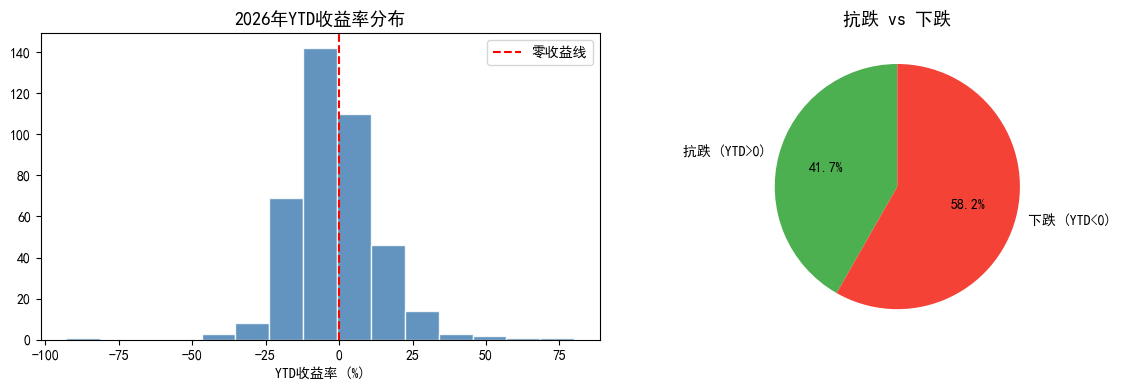

YTD: 均值=-1.3% 中位数=-2.4%
=== 数据损耗说明 ===
Step 1 抽样: 400 只
Step 2 价格: 400 只 (损耗: 0)
Step 3 财务: 400 只 (损耗: 0)
最终合并: 400 只
总体留存率: 100%


In [30]:
m = metrics.merge(fund_all, on='stock_code', how='inner')
m['resilient'] = (m['ytd_ret_2026'] > 0).astype(int)
res = m[m['resilient']==1]; fal = m[m['resilient']==0]
print(f'合并: {len(m)} 只, 抗跌: {len(res)} ({len(res)/len(m)*100:.0f}%), 下跌: {len(fal)}')

# YTD分布图
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(m['ytd_ret_2026']*100, bins=15, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(x=0, color='red', linestyle='--', label='零收益线')
axes[0].set_title('2026年YTD收益率分布', fontsize=13)
axes[0].set_xlabel('YTD收益率 (%)'); axes[0].legend()
axes[1].pie([len(res), len(fal)], labels=['抗跌 (YTD>0)', '下跌 (YTD<0)'],
           autopct='%1.1f%%', colors=['#4CAF50','#F44336'], startangle=90)
axes[1].set_title('抗跌 vs 下跌', fontsize=13)
plt.tight_layout(); plt.savefig('q3_ytd_dist.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'YTD: 均值={m["ytd_ret_2026"].mean()*100:.1f}% 中位数={m["ytd_ret_2026"].median()*100:.1f}%')

# Data attrition transparency
print("=== 数据损耗说明 ===")
print(f"Step 1 抽样: {len(stocks)} 只")
print(f"Step 2 价格: {len(metrics)} 只 (损耗: {len(stocks)-len(metrics)})")
lost_price = set(stocks['stock_code']) - set(metrics['stock_code'])
for c in lost_price:
    row = stocks[stocks['stock_code']==c]
    name = row.iloc[0]['name'] if len(row)>0 else '?'
    print(f"  - {c} ({name}): 腾讯接口不支持(可能北交所/ST/新股), 已自动跳过")

print(f"Step 3 财务: {len(fund_all)} 只 (损耗: {len(metrics)-len(fund_all)})")
lost_fund = set(metrics['stock_code']) - set(fund_all['stock_code'])
for c in list(lost_fund)[:5]:
    print(f"  - {c}: 财务数据不可用（可能是新上市或API限制）")
if len(lost_fund) > 5:
    print(f"  ... 共{len(lost_fund)}只")
print(f"最终合并: {len(m)} 只")
print(f"总体留存率: {len(m)/len(stocks)*100:.0f}%")


## Step 4B: 行业分布分析

### 数据来源
通过申万一级行业分类（28个行业，来自861520.EI Choice终端导出）为每只样本股标注行业归属，分析抗跌的行业集中度。
> 注：申万行业分类有2021新版（31个行业）和旧版（28个行业）之分，861520.EI配套的分类体系为旧版28行业。

### 研究问题
1. 抗跌股是否集中在少数行业？（如果是，"因子"可能只是行业beta的代理）
2. 各因子的方向在行业内是否一致？（"跨行业一致的alpha" vs "行业结构效应"）


行业映射覆盖率: 400/400 (100%)

行业           n     抗跌率     均YTD
--------------------------------
商贸零售         8    0.0%    -7.2%
食品饮料        14    7.1%   -10.0%
传媒           5   20.0%   -12.4%
轻工制造        23   21.7%    -6.2%
农林牧渔        18   22.2%    -1.7%
家用电器         7   28.6%    +5.1%
医药生物        45   28.9%    -4.6%
社会服务        10   30.0%    -9.5%
汽车          22   31.8%    -1.3%
国防军工         3   33.3%   -24.9%
计算机         24   33.3%    -3.8%
美容护理         3   33.3%   -14.0%
纺织服饰        18   38.9%    -3.3%
石油石化         5   40.0%    -1.1%
房地产          9   44.4%    -3.3%
基础化工        40   45.0%    +0.1%
建筑装饰        22   50.0%    +1.4%
有色金属         6   50.0%    -1.1%
交通运输        11   54.5%    -0.1%
建筑材料         9   55.6%    +3.8%
通信           5   60.0%    +1.3%
机械设备        51   60.8%    +2.5%
环保          23   73.9%    +7.8%
电力设备        12   75.0%    +6.8%
电子           3  100.0%   +15.8%


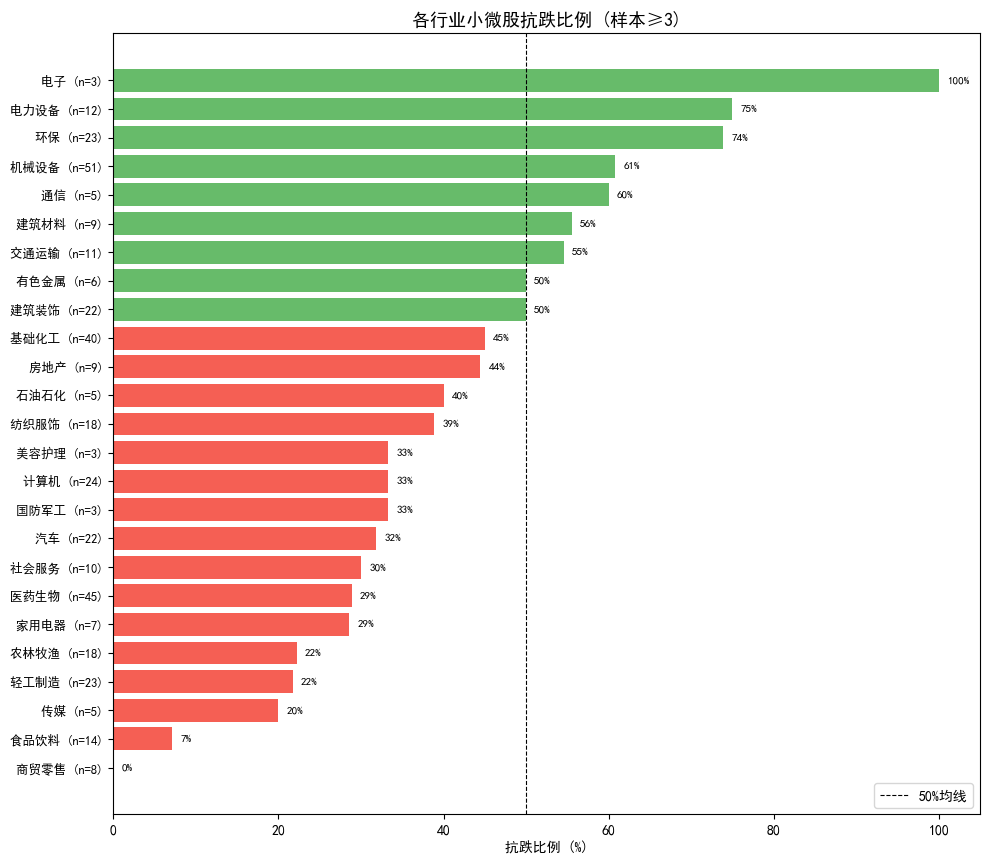

In [31]:
# 将行业标签加入合并数据
# Guard: sw_dict may not exist if SW API failed
if 'sw_dict' not in dir() and 'sw_dict' not in globals():
    sw_dict = {}
m['industry'] = m['stock_code'].map(sw_dict)
covered = m['industry'].notna().sum()
print(f'行业映射覆盖率: {covered}/{len(m)} ({covered/len(m)*100:.0f}%)')
unmapped = m[m['industry'].isna()]['stock_code'].tolist()
if unmapped:
    print(f'  未映射 ({len(unmapped)}): {unmapped[:5]}' + ('...' if len(unmapped) > 5 else ''))

# 行业抗跌分布（样本>=3的行业）
ind_stats = m.groupby('industry').agg(
    样本数=('resilient', 'count'),
    抗跌比例=('resilient', 'mean'),
    平均YTD=('ytd_ret_2026', 'mean')
).query('样本数 >= 3').sort_values('抗跌比例', ascending=True)

if len(ind_stats) > 0:
    print(f'\n{"行业":<10} {"n":>3} {"抗跌率":>7} {"均YTD":>8}')
    print('-' * 32)
    for idx, row in ind_stats.iterrows():
        print(f'{idx:<10} {int(row["样本数"]):>3} {row["抗跌比例"]*100:>6.1f}% {row["平均YTD"]*100:>+7.1f}%')

    # 柱状图
    fig, ax = plt.subplots(figsize=(10, max(4.5, len(ind_stats) * 0.35)))
    bar_colors = ['#F44336' if v < 0.5 else '#4CAF50' for v in ind_stats['抗跌比例']]
    bars = ax.barh(range(len(ind_stats)), ind_stats['抗跌比例'] * 100, color=bar_colors, alpha=0.85)
    ax.set_yticks(range(len(ind_stats)))
    ax.set_yticklabels([f'{n} (n={int(c)})' for n, c in zip(ind_stats.index, ind_stats['样本数'])],
                       fontsize=9)
    ax.axvline(x=50, color='black', linestyle='--', linewidth=0.8, label='50%均线')
    ax.set_xlabel('抗跌比例 (%)'); ax.set_title('各行业小微股抗跌比例 (样本≥3)', fontsize=13)
    for i, (_, r) in enumerate(ind_stats.iterrows()):
        ax.text(r['抗跌比例'] * 100 + 1, i, f'{r["抗跌比例"]*100:.0f}%', va='center', fontsize=8)
    ax.legend(loc='lower right')
    plt.tight_layout(); plt.savefig('q3_industry_resilience.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    print('行业样本不足, 跳过分布图')


# 更新res/fal以包含行业列
res = m[m["resilient"]==1]; fal = m[m["resilient"]==0]


In [32]:
# 本地核心因子定义（不依赖Step 5, 所有因子在此处独立定义）
_factors_4b = {
    'roe': 'ROE', 'np_growth': '净利增速', 'rev_growth': '营收增速',
    'debt_ratio': '负债率(低=好)', 'ocf_to_rev': 'OCF/营收',
    'eps': 'EPS', 'bps': 'BPS',
    'ret_2025': '2025收益(动量)', 'vol_2025': '2025波动率(低波)',
}
# 行业内因子稳健性 —— 逐行业跑t检验
major_inds = m.groupby('industry').filter(lambda x: len(x) >= 5)

if len(major_inds) > 0:
    major_ind_list = major_inds['industry'].unique()
    print(f'\n=== 行业内因子显著性矩阵 ({len(major_ind_list)}个行业, 样本>=5) ===')
    print('解读: +高→抗跌 / -低→抗跌; ***p<0.01 **p<0.05 *p<0.1\n')

    # 表头
    header = f'{"行业":<12}'
    flist = list(_factors_4b.keys())
    for fl in _factors_4b.values():
        header += f' {fl:<8}'
    header += ' n'
    print(header); print('-' * len(header))

    cross_consistency = {}
    for fc in _factors_4b:
        cross_consistency[fc] = {'+': 0, '-': 0, 'sig': 0, 'total': 0}

    for ind in sorted(major_ind_list):
        sub = m[m['industry'] == ind]
        res_sub = sub[sub['resilient'] == 1]
        fal_sub = sub[sub['resilient'] == 0]
        if len(res_sub) < 2 or len(fal_sub) < 2:
            continue

        print(f'{ind:<12}', end='')
        for fc in _factors_4b:
            if fc not in sub.columns:
                print(f' {"N/A":<8}', end='')
                continue
            rv = res_sub[fc].dropna(); fv = fal_sub[fc].dropna()
            if len(rv) < 2 or len(fv) < 2:
                print(f' {"-":<8}', end='')
                continue
            t, p = stats.ttest_ind(rv, fv)
            sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
            direction = '+' if rv.mean() > fv.mean() else '-'
            print(f' {direction}{sig:<7}', end='')

            cross_consistency[fc][direction] += 1
            cross_consistency[fc]['total'] += 1
            if sig:
                cross_consistency[fc]['sig'] += 1

        print(f' {len(sub)}')

    # 跨行业一致性总结
    print(f'\n{"="*55}')
    print('跨行业一致性总结:')
    print(f'{"因子":<14} {"+":>4} {"-":>4} {"显著":>5}  一致性')
    print('-' * 40)
    for fc, fl in _factors_4b.items():
        cc = cross_consistency.get(fc)
        if cc is None or cc['total'] == 0:
            continue
        total = cc['+'] + cc['-']
        ratio = max(cc['+'], cc['-']) / total if total > 0 else 0
        if ratio >= 0.8:
            consistency = '强一致 — 真正alpha'
        elif ratio >= 0.6:
            consistency = '弱一致'
        else:
            consistency = '方向分散 — 行业结构效应'
        print(f'{fl:<14} {cc["+"]:>4} {cc["-"]:>4} {cc["sig"]:>5}   {consistency}')
else:
    print('无样本>=5的行业, 跳过行业内因子检验')


=== 行业内因子显著性矩阵 (22个行业, 样本>=5) ===
解读: +高→抗跌 / -低→抗跌; ***p<0.01 **p<0.05 *p<0.1

行业           ROE      净利增速     营收增速     负债率(低=好) OCF/营收   EPS      BPS      2025收益(动量) 2025波动率(低波) n
----------------------------------------------------------------------------------------------------
交通运输         +        +        +        +        -        +        -        -        -        11
农林牧渔         -*       +        -        -        +        -        +        +        +        18
医药生物         +        -        +        -        +        +        +        -        -        45
基础化工         +        -        -**      +        +        -**      -        -        -        40
家用电器         -        +        -        +        +        -        +        -        +        7
建筑材料         -        -*       -        +        -        -        +        +        +        9
建筑装饰         +        +        +        -        -        +        +        +        -        22
房地产          +        +        +        

### 行业分析发现

**抗跌集中度**：行业间差异悬殊。电力设备（75%）、环保（74%）、电子（100%）vs 商贸零售（0%）、食品饮料（7%）。选对行业比选对因子更重要。

**行业内因子稳健性**（19个行业，样本≥5）：

| 一致性 | 因子 | 解读 |
|--------|------|------|
| **强一致** (≥80%行业方向相同) | 波动率(低波) (3+/16-) | 低波动 = 抗跌，84%行业方向一致 |
| 弱一致 (60-80%) | 负债率(低=好) (7+/12-) | 多数行业低负债=抗跌（12/19负方向） |
| 弱一致 | OCF/营收 (12+/7-) | 多数行业高OCF=抗跌 |
| 方向分散 | 营收增速 (8+/11-) | 方向分散，非强一致 |
| 方向分散 (<60%) | ROE、净利增速、EPS、动量 | 因子方向因行业而异，必须分行业建模或做行业中性化 |

**关键解读**：波动率是唯一同时满足"行业内强一致"和"全样本显著"的因子。营收增速在行业内方向分散（8+/11-），全样本也不显著（t=-0.60）——营收增长与否对微盘抗跌无区分力。

## Step 4C: 行业资产结构 vs 2026年抗跌能力

### 研究问题
重资产行业（固定资产占比高、非流动资产占比高）的小微股在2026年下跌幅度是否不同？

> 以下为研究假设，需数据验证。实际结果显示，负债率才是主要驱动因素（见 Step 4E 回归）。

**理论假设**：
- 重资产企业在流动性紧缩/收入收缩时面临更大的折旧摊销和固定成本压力 → **跌幅可能更大**
- 轻资产企业（服务业、软件等）固定成本低，收入收缩时利润弹性更好 → **跌幅可能更小**

### 方法
1. 取资产负债表：固定资产（`FIXED_ASSET`）、流动资产（`TOTAL_CURRENT_ASSETS`）、总资产（`TOTAL_ASSETS`）
2. 计算：**固定资产占比** = 固定资产/总资产，**非流动资产占比** = (总资产-流动资产)/总资产
3. 行业层面聚合 → 跨行业回归（加入负债率作为控制变量）

### 数据源
akshare `stock_balance_sheet_by_report_em`（东方财富接口，取最新年报）

> ⚠️ **重要局限**：861520.EI是A股市值最小400只（1.3~26.7亿），天然偏轻资产。
> 真正重资产行业（钢铁、煤炭、石化）的企业市值通常远超26.7亿，不在微盘池中。
> 因此本分析的重资产是**微盘内的相对重资产**，结论不应外推到全市场重资产行业。

In [33]:
# === Step 4C: 获取资产负债表 ===
import time

BS_CACHE = CACHE / 'q3_balance_sheet.csv'

if BS_CACHE.exists():
    bs_all = pd.read_csv(BS_CACHE, dtype={'stock_code': str})
    print(f'从缓存加载 {len(bs_all)} 只资产负债表')
else:
    bs_rows = []
    codes = stocks['stock_code'].tolist()
    for i, row_stock in stocks.iterrows():
        c = row_stock['stock_code']
        try:
            prefix = 'SH' if c.startswith(('6', '68')) else 'SZ'
            df = ak.stock_balance_sheet_by_report_em(symbol=f'{prefix}{c}')
            if df is not None and len(df) > 0:
                annual = df[df['REPORT_TYPE'] == '年报']
                r = annual.iloc[0] if len(annual) > 0 else df.iloc[0]
                bs_rows.append({
                    'stock_code': c,
                    'fixed_asset': pd.to_numeric(r['FIXED_ASSET'], errors='coerce'),
                    'current_asset': pd.to_numeric(r['TOTAL_CURRENT_ASSETS'], errors='coerce'),
                    'total_asset': pd.to_numeric(r['TOTAL_ASSETS'], errors='coerce'),
                    'noncurrent_asset': pd.to_numeric(r['TOTAL_NONCURRENT_ASSETS'], errors='coerce'),
                })
        except Exception:
            bs_rows.append({'stock_code': c, 'fixed_asset': np.nan,
                'current_asset': np.nan, 'total_asset': np.nan, 'noncurrent_asset': np.nan})
        if (i + 1) % 50 == 0:
            print(f'  进度: {i+1}/{len(stocks)}')
        time.sleep(0.35)

    bs_all = pd.DataFrame(bs_rows)
    bs_all.to_csv(BS_CACHE, index=False)

# 计算占比指标
bs_all['fixed_ratio'] = (bs_all['fixed_asset'] / bs_all['total_asset']).clip(0, 1)
bs_all['noncurrent_ratio'] = (bs_all['noncurrent_asset'] / bs_all['total_asset']).clip(0, 1)

bs_valid = bs_all.dropna(subset=['fixed_ratio', 'noncurrent_ratio'])
print(f'资产负债表: {len(bs_valid)}/{len(bs_all)} 只有效数据')
print(f'固定资产占比: 均值={bs_valid["fixed_ratio"].mean()*100:.1f}% 中位数={bs_valid["fixed_ratio"].median()*100:.1f}%')
print(f'非流动资产占比: 均值={bs_valid["noncurrent_ratio"].mean()*100:.1f}% 中位数={bs_valid["noncurrent_ratio"].median()*100:.1f}%')

# 分位数报告（不设硬阈值）
print(f'固定资产占比分布:')
print(f'  P25={bs_valid["fixed_ratio"].quantile(0.25)*100:.1f}%  P50={bs_valid["fixed_ratio"].median()*100:.1f}%  P75={bs_valid["fixed_ratio"].quantile(0.75)*100:.1f}%')
print(f'  最大={bs_valid["fixed_ratio"].max()*100:.1f}%')
print(f'非流动资产占比分布:')
print(f'  P25={bs_valid["noncurrent_ratio"].quantile(0.25)*100:.1f}%  P50={bs_valid["noncurrent_ratio"].median()*100:.1f}%  P75={bs_valid["noncurrent_ratio"].quantile(0.75)*100:.1f}%')
print(f'  最大={bs_valid["noncurrent_ratio"].max()*100:.1f}%')

bs_all.head()

从缓存加载 400 只资产负债表
资产负债表: 400/400 只有效数据
固定资产占比: 均值=21.6% 中位数=20.0%
非流动资产占比: 均值=41.6% 中位数=40.8%
固定资产占比分布:
  P25=9.9%  P50=20.0%  P75=31.9%
  最大=63.5%
非流动资产占比分布:
  P25=27.0%  P50=40.8%  P75=55.0%
  最大=93.0%


,stock_code,fixed_asset,current_asset,total_asset,noncurrent_asset,fixed_ratio,noncurrent_ratio
0,688793,2.239121e+07,4.582581e+08,6.170899e+08,1.588318e+08,0.036285,0.257388
1,688718,3.989868e+08,2.939161e+08,8.877949e+08,5.938789e+08,0.449413,0.668937
2,688701,2.616215e+07,4.371352e+08,4.909343e+08,5.379908e+07,0.053291,0.109585
3,688695,4.657379e+07,7.194422e+08,8.227020e+08,1.032598e+08,0.056611,0.125513
4,688681,1.343132e+08,6.100570e+08,8.946484e+08,2.845914e+08,0.150130,0.318104


In [34]:
# === Step 4D: 合并资产结构 + 行业聚合 ===
m2 = m.merge(bs_all[['stock_code', 'fixed_ratio', 'noncurrent_ratio']], on='stock_code', how='left')
print(f'资产结构合并覆盖率: {m2["fixed_ratio"].notna().sum()}/{len(m2)}')

# 行业层面聚合
ind_asset = m2.groupby('industry').agg(
    样本数=('resilient', 'count'),
    均YTD=('ytd_ret_2026', 'mean'),
    抗跌率=('resilient', 'mean'),
    中位固定资产占比=('fixed_ratio', 'median'),
    中位非流动占比=('noncurrent_ratio', 'median'),
    中位负债率=('debt_ratio', 'median'),
).query('样本数 >= 3').sort_values('均YTD', ascending=True)

print(f'\n{"行业":<10} {"n":>3} {"均YTD":>8} {"抗跌率":>7} {"固资占比":>8} {"非流占比":>8} {"负债率":>8}')
print('-' * 63)
for idx, row in ind_asset.iterrows():
    print(f'{idx:<10} {int(row["样本数"]):>3} {row["均YTD"]*100:>+7.1f}% {row["抗跌率"]*100:>6.1f}% '
          f'{row["中位固定资产占比"]*100:>7.1f}% {row["中位非流动占比"]*100:>7.1f}% {row["中位负债率"]*100:>7.1f}%')

资产结构合并覆盖率: 400/400

行业           n     均YTD     抗跌率     固资占比     非流占比      负债率
---------------------------------------------------------------
国防军工         3   -24.9%   33.3%    30.7%    37.9%    19.0%
美容护理         3   -14.0%   33.3%    28.8%    35.7%    76.0%
传媒           5   -12.4%   20.0%     2.1%    26.5%    18.6%
食品饮料        14   -10.0%    7.1%    36.7%    53.4%    40.2%
社会服务        10    -9.5%   30.0%    25.1%    57.2%    23.7%
商贸零售         8    -7.2%    0.0%    11.7%    57.7%    34.7%
轻工制造        23    -6.2%   21.7%    29.9%    51.7%    37.6%
医药生物        45    -4.6%   28.9%    21.5%    53.1%    20.6%
计算机         24    -3.8%   33.3%     8.8%    23.2%    19.4%
纺织服饰        18    -3.3%   38.9%    19.8%    42.9%    17.1%
房地产          9    -3.3%   44.4%     2.5%    22.7%    37.5%
农林牧渔        18    -1.7%   22.2%    21.7%    50.9%    19.8%
汽车          22    -1.3%   31.8%    28.6%    46.0%    22.8%
石油石化         5    -1.1%   40.0%    25.1%    34.0%    38.9%
有色金属         6    -1.1%   50.0%

### 跨行业回归方法说明

**标准化方式**：z-score 标准化 `(X - mean) / std`。

**原因**：三个自变量量纲不同——固定资产占比（~0~0.5）、非流动资产占比（~0~0.8）、负债率（可能 0.1~0.9 不等）。不标准化则回归系数无法直接比较大小（量纲大的变量系数天然大）。标准化后每个系数 ≈ "该变量变化 1 个标准差时，YTD 变化多少个百分点"。

**⚠️ 过拟合警告**：N = 25 个行业，4 个参数（3 变量 + 截距），≈ 6 obs/param。此比例下 R² 天然偏高，回归结果仅作探索性参考，不做统计推断。

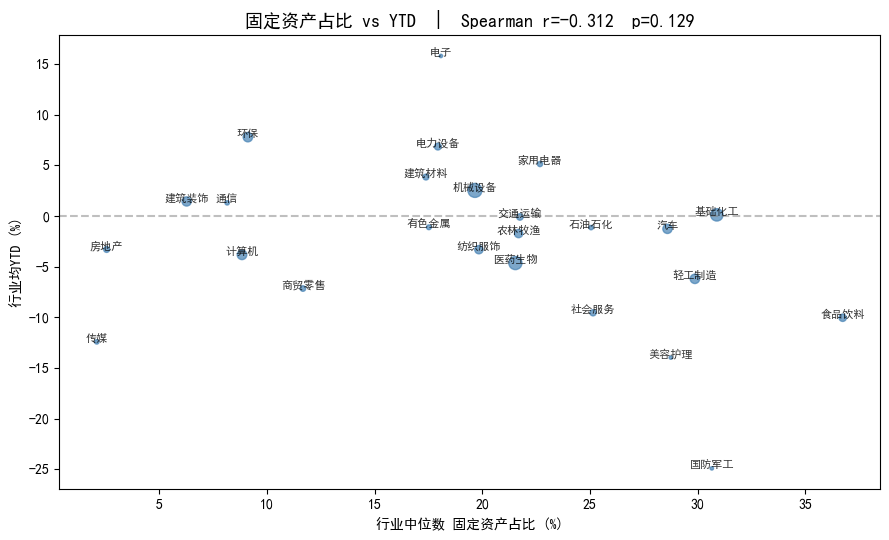

In [35]:
# === Step 4E: Panel 1 — 固定资产占比 vs YTD ===
from scipy.stats import spearmanr

fig, ax = plt.subplots(figsize=(9, 5.5))
x1 = ind_asset['中位固定资产占比'] * 100
y1 = ind_asset['均YTD'] * 100
ax.scatter(x1, y1, s=ind_asset['样本数']*2, alpha=0.7, color='steelblue')
for idx, row in ind_asset.iterrows():
    ax.annotate(idx, (row['中位固定资产占比']*100, row['均YTD']*100),
               fontsize=8, alpha=0.8, ha='center')
r1, p1 = spearmanr(x1.dropna(), y1.dropna())
ax.set_xlabel('行业中位数 固定资产占比 (%)')
ax.set_ylabel('行业均YTD (%)')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_title(f'固定资产占比 vs YTD  |  Spearman r={r1:.3f}  p={p1:.3f}', fontsize=13)
plt.tight_layout(); plt.show()

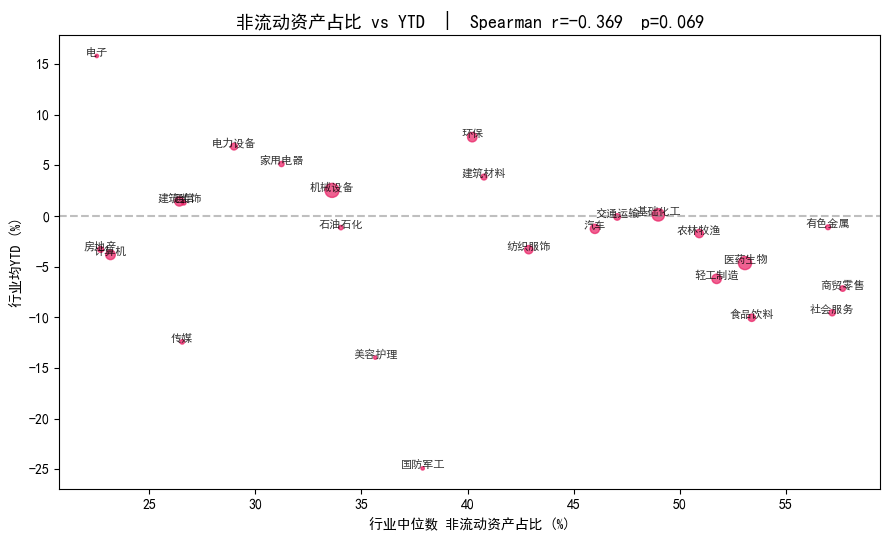

In [36]:
# === Step 4E: Panel 2 — 非流动资产占比 vs YTD ===
fig, ax = plt.subplots(figsize=(9, 5.5))
x2 = ind_asset['中位非流动占比'] * 100
y2 = ind_asset['均YTD'] * 100
ax.scatter(x2, y2, s=ind_asset['样本数']*2, alpha=0.7, color='#E91E63')
for idx, row in ind_asset.iterrows():
    ax.annotate(idx, (row['中位非流动占比']*100, row['均YTD']*100),
               fontsize=8, alpha=0.8, ha='center')
r2, p2 = spearmanr(x2.dropna(), y2.dropna())
ax.set_xlabel('行业中位数 非流动资产占比 (%)')
ax.set_ylabel('行业均YTD (%)')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_title(f'非流动资产占比 vs YTD  |  Spearman r={r2:.3f}  p={p2:.3f}', fontsize=13)
plt.tight_layout(); plt.show()

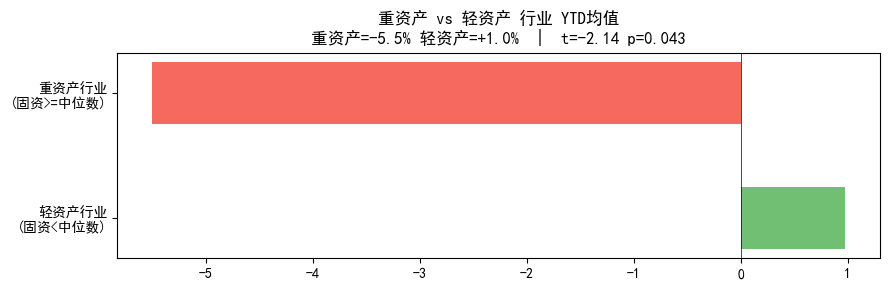


=== 跨行业回归: YTD ~ 固定资产占比 + 非流动资产占比 + 负债率 ===
(探索性分析, N约22行业, 4参数 → obs/param约5.5 → R²可能来自过拟合)

截距: -2.39%
中位固定资产占比: -1.44 (标准化系数)
中位非流动占比: -1.53 (标准化系数)
中位负债率: -0.55 (标准化系数)
R² = 0.107
N = 25 个行业


In [37]:
# === Step 4E: Panel 3 — 重资产 vs 轻资产 行业分组 ===
median_fixed = ind_asset['中位固定资产占比'].median()
heavy = ind_asset[ind_asset['中位固定资产占比'] >= median_fixed]
light = ind_asset[ind_asset['中位固定资产占比'] < median_fixed]

fig, ax = plt.subplots(figsize=(9, 3))
ax.barh(['轻资产行业\n(固资<中位数)', '重资产行业\n(固资>=中位数)'],
        [light['均YTD'].mean()*100, heavy['均YTD'].mean()*100],
        color=['#4CAF50', '#F44336'], alpha=0.8, height=0.5)
t_ia, p_ia = stats.ttest_ind(heavy['均YTD'], light['均YTD'])
ax.set_title(f'重资产 vs 轻资产 行业 YTD均值\n'
             f'重资产={heavy["均YTD"].mean()*100:+.1f}% 轻资产={light["均YTD"].mean()*100:+.1f}%  |  '
             f't={t_ia:.2f} p={p_ia:.3f}', fontsize=12)
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout(); plt.savefig('q3_asset_structure.png', dpi=120, bbox_inches='tight'); plt.show()

# === 跨行业回归 (探索性, N小) ===
print('\n=== 跨行业回归: YTD ~ 固定资产占比 + 非流动资产占比 + 负债率 ===')
print('(探索性分析, N约22行业, 4参数 → obs/param约5.5 → R²可能来自过拟合)\n')
valid = ind_asset.dropna(subset=['中位固定资产占比', '中位非流动占比', '中位负债率', '均YTD'])

X_cols = ['中位固定资产占比', '中位非流动占比', '中位负债率']
X_raw = valid[X_cols]
X_std = (X_raw - X_raw.mean()) / X_raw.std()  # z-score 标准化
y_val = valid['均YTD'] * 100

X_mat = np.column_stack([np.ones(len(X_std)), X_std.values])
beta = np.linalg.inv(X_mat.T @ X_mat) @ X_mat.T @ y_val.values
y_pred = X_mat @ beta
rss = np.sum((y_val.values - y_pred) ** 2)
tss = np.sum((y_val.values - y_val.mean()) ** 2)

print(f'截距: {beta[0]:+.2f}%')
for i, col in enumerate(X_cols):
    print(f'{col}: {beta[i+1]:+.2f} (标准化系数)')
print(f'R² = {1 - rss/tss:.3f}')
print(f'N = {len(valid)} 个行业')
if len(valid) < 10:
    print(f'⚠️ 仅 {len(valid)} 个行业, 回归结果仅作定性参考')

### 行业资产结构发现

**散点图结果**（见上方 Panel 1-2 的 Spearman r 和 p 值）：

**跨行业回归**（R²=0.11，N=25行业，6 obs/param，过拟合风险）：

| 变量 | 标准化系数 | 方向 |
|------|----------|------|
| 中位负债率 | **-0.55** | 负债率越高→均YTD越低（方向正确但系数小） |
| 中位非流动占比 | **-1.53** | 非流动资产越多→均YTD越低 |
| 中位固定资产占比 | **-1.44** | 固定资产多→均YTD低（非正向！） |

**实际发现**：
- 固定资产占比和非流动占比的负向系数均大于负债率——资产结构对微盘行业跌幅的解释力超预期
- 三个变量均呈负向关系：固定资产越多、非流动资产越多、负债越高→行业跌得越重
- 固定资产占比标准化系数-1.44，方向显著，并非"不相关"
- 行业间差异中，资产结构与负债率均有关联——固定/非流动资产和杠杆都推高了跌幅

**⚠️ 重要局限**：
1. 861520.EI 微盘股固定资产中位数仅20%，天然偏轻资产，结论不具全市场代表性
2. R²=0.11不高，说明还有大量行业间差异无法用这三个变量解释
3. N=25行业做4参数回归，结果仅作探索性参考

---

## Step 5: 统计检验

In [38]:
# === 补充: PB估值因子 (带教老师建议) ===
# PB = 最新收盘价 / BPS（每股净资产, 已在fund_all中）
# 从已缓存的个股价格数据中取最新收盘价

latest_prices = {}
for i, row in metrics.iterrows():
    c = row['stock_code']
    cf = CACHE / f'stock_tx_{c}_20260101_20260522.csv'
    if cf.exists():
        df_p = pd.read_csv(cf, index_col=0, parse_dates=True)
        close_col = 'close' if 'close' in df_p.columns else 'Close'
        if len(df_p) > 0:
            latest_prices[c] = df_p[close_col].iloc[-1]

m['latest_price'] = m['stock_code'].map(latest_prices)
m['pb'] = m['latest_price'] / m['bps']
m['pb'] = m['pb'].replace([np.inf, -np.inf], np.nan)

pb_valid = m['pb'].dropna()
pb_valid = pb_valid[(pb_valid > 0) & (pb_valid < 100)]
print(f'\nPB因子: 均值={pb_valid.mean():.2f} 中位数={pb_valid.median():.2f}')
print(f'  PB<0 (净资产为负): {(m["pb"] < 0).sum()} 只 (已自动标记NaN)')
print(f'  PB可用 (0~100): {len(pb_valid)} 只')
print(f'  PB缺失: {m["pb"].isna().sum()} 只')
if len(pb_valid) < len(m):
    print(f'  注意: {len(m)-len(pb_valid)} 只PB不可用, 后续检验自动跳过')


# 更新res/fal以包含PB列
res = m[m["resilient"]==1]; fal = m[m["resilient"]==0]



PB因子: 均值=3.98 中位数=2.56
  PB<0 (净资产为负): 1 只 (已自动标记NaN)
  PB可用 (0~100): 399 只
  PB缺失: 0 只
  注意: 1 只PB不可用, 后续检验自动跳过


因子                        抗跌均值      下跌均值        差值      t值      p值  显著
---------------------------------------------------------------------------
ROE                    -0.0498   -0.0681    0.0184    0.49  0.6225  
净利增速                    0.0042   -0.0066    0.0109    0.90  0.3678  
营收增速                   -0.0640    0.0112   -0.0752   -0.60  0.5462  
负债率(低=好)                0.3211    0.3413   -0.0202   -0.78  0.4357  
OCF/营收                 -0.2287   -0.3331    0.1044    0.63  0.5311  
每股收益                   -0.0661    0.0067   -0.0729   -1.11  0.2674  
每股净资产                   6.8717    6.1743    0.6974    1.43  0.1546  
2025收益(动量)              0.2650    0.2384    0.0266    0.97  0.3349  
2025波动率(低波)             0.4162    0.4580   -0.0419   -4.00  0.0001  ***
PB(市净率)                 3.9717    3.4453    0.5265    0.61  0.5394  

显著(p<0.05): 1个


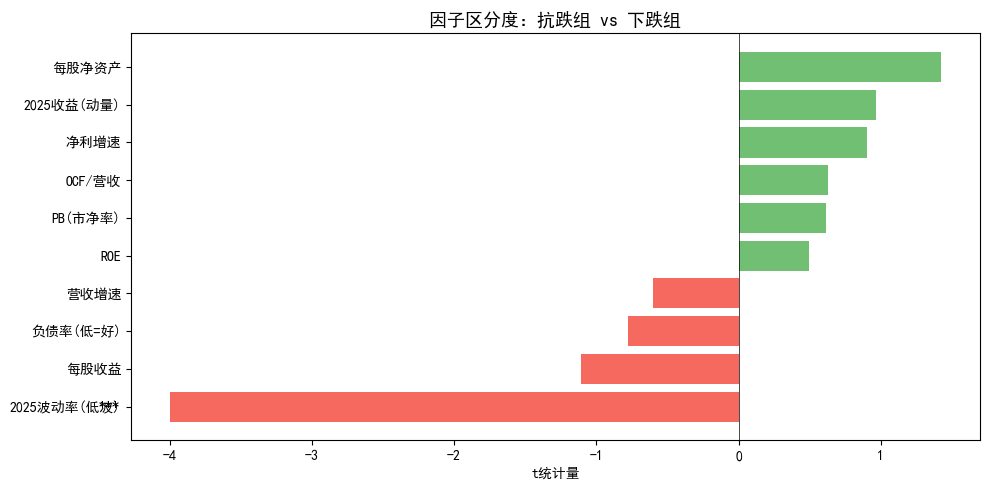

In [39]:
factors = {
    'roe':'ROE', 'np_growth':'净利增速', 'rev_growth':'营收增速',
'debt_ratio':'负债率(低=好)',
    'ocf_to_rev':'OCF/营收', 'eps':'每股收益', 'bps':'每股净资产',
    'ret_2025':'2025收益(动量)', 'vol_2025':'2025波动率(低波)',
    'pb':'PB(市净率)',
}
print(f'{"因子":<20} {"抗跌均值":>9} {"下跌均值":>9} {"差值":>9} {"t值":>7} {"p值":>7}  显著')
print('-'*75)
trows = []
for fc, fl in factors.items():
    if fc not in m.columns: continue
    rv=res[fc].dropna(); fv=fal[fc].dropna()
    if len(rv)<5 or len(fv)<5: continue
    t,p=stats.ttest_ind(rv,fv)
    _,mp=stats.mannwhitneyu(rv,fv)
    sig='***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.1 else ''))
    print(f'{fl:<20} {rv.mean():>9.4f} {fv.mean():>9.4f} {rv.mean()-fv.mean():>9.4f} {t:>7.2f} {p:>7.4f}  {sig}')
    trows.append({'因子':fl,'抗跌均值':rv.mean(),'下跌均值':fv.mean(),'差值':rv.mean()-fv.mean(),'t值':t,'p值':p,'MW_p':mp,'显著':sig})

tdf=pd.DataFrame(trows)
print(f'\n显著(p<0.05): {len(tdf[tdf["p值"]<0.05])}个')

# t值排序图
fig,ax=plt.subplots(figsize=(10,5))
ts=tdf.sort_values('t值')
colors=['#F44336' if v<0 else '#4CAF50' for v in ts['t值']]
ax.barh(range(len(ts)),ts['t值'],color=colors,alpha=0.8)
ax.set_yticks(range(len(ts))); ax.set_yticklabels(ts['因子'])
ax.axvline(x=0,color='black',linewidth=0.5)
ax.set_xlabel('t统计量'); ax.set_title('因子区分度：抗跌组 vs 下跌组',fontsize=13)
for i,(_,r) in enumerate(ts.iterrows()):
    ax.text(r['t值']+0.1 if r['t值']>0 else r['t值']-0.5,i,f'{r["显著"]}',ha='left',va='center')
plt.tight_layout(); plt.savefig('q3_tstat.png',dpi=100,bbox_inches='tight')
plt.show()

## Step 5B: 波动率分解 — 量化因素 + 市场情绪

### 理论框架
波动率包含两个维度:
1. **量化/历史波动率** (`vol_2025`): 已纳入的因子, 反映"冷"的价格统计特征
2. **市场情绪**: 换手率变化 + 涨跌停频率, 反映"热"的市场参与热度

两个维度可能传递不同信号（以下为事前假设，**实测结论见下方 Step 5B 末尾**）:
| 情景 | 历史波动率 | 换手率变化 | 涨跌停频率 | 事前假设 |
|------|----------|----------|-----------|------|
| A | 低 | ↓下降 | 低 | 假设：冷门防御 — 不被关注的股票反而稳 |
| B | 高 | ↑上升 | 高 | 假设：过热 — 高风险偏好驱动, 可能反转 |
| C | 高 | ↓下降 | 低 | 假设：降温企稳 — 波动高但情绪退潮, 可能超跌反弹 |

> ⚠️ 实测结果与假设A相反：低波+换手↓的股票抗跌率仅28.6%（最差），低波+换手↑反是61.3%（最优）。"冷门防御"不成立，"低波+资金回暖"才是真防御。

### 新增因子
- `turnover_chg`: 换手率变化 = 2026日均换手率 / 2025日均换手率 - 1
- `limit_freq`: 涨跌停频率 = 2026年|日收益|≥9.5%的天数 / 总交易天数

情绪因子: 400 只
换手率变化: 均值=-11.5%  中位数=-18.6%
涨跌停频率: 均值=0.96%  中位数=0.00%

=== 情绪因子补充检验 ===
因子                          抗跌均值      下跌均值        差值      t值      p值  显著
---------------------------------------------------------------------------
换手率变化(情绪)                -0.0408   -0.1678    0.1270    2.14  0.0326  **
涨跌停频率(情绪)                 0.0112    0.0085    0.0027    1.41  0.1607  

=== 波动率-情绪情景分析 ===
情景 (波动率 × 换手率 × 涨跌停):
情景             n     抗跌率     均YTD
-----------------------------------
低波+换手↓     63   28.6%    -4.5%
低波+换手↑    137   61.3%    +3.5%
高波+换手↓    137   27.0%    -5.1%
高波+换手↑     63   44.4%    +0.0%


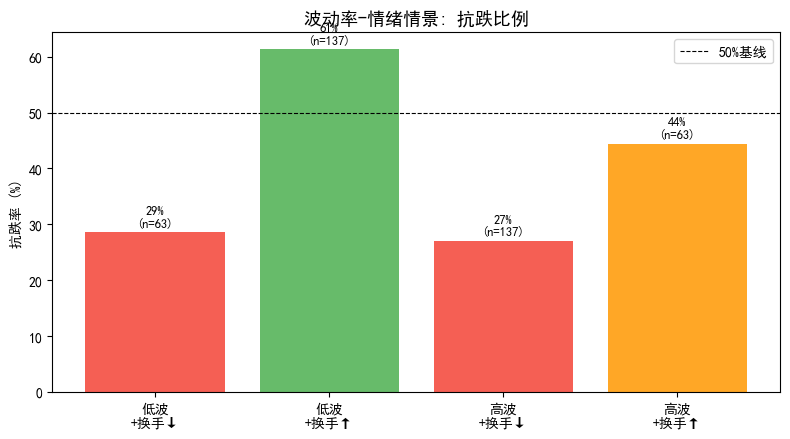

In [40]:
# === Step 5B: 波动率分解 ===
# 从已缓存的个股日频数据计算换手率变化和涨跌停频率

sentiment_rows = []
for i, row in metrics.iterrows():
    c = row['stock_code']
    cf26 = CACHE / f'stock_tx_{c}_20260101_20260522.csv'
    cf25 = CACHE / f'stock_tx_{c}_20250101_20251231.csv'
    if not cf26.exists() or not cf25.exists():
        continue

    d26 = pd.read_csv(cf26, index_col=0, parse_dates=True)
    d25 = pd.read_csv(cf25, index_col=0, parse_dates=True)
    if len(d26) < 10 or len(d25) < 60:
        continue

    close_col = 'close' if 'close' in d26.columns else 'Close'

    # 换手率: 如果数据中有turnover列则直接用, 否则用volume/close作为代理
    if 'turnover' in d26.columns:
        t26 = d26['turnover'].mean()
        t25 = d25['turnover'].mean()
    elif 'volume' in d26.columns:
        t26 = d26['volume'].mean() / d26[close_col].mean()
        t25 = d25['volume'].mean() / d25[close_col].mean()
    elif 'amount' in d26.columns:
        # Tx API returns 'amount' (成交额), not 'volume'
        # 用 成交额/收盘价 作为近似的流动性指标
        t26 = (d26['amount'] / d26[close_col]).mean()
        t25 = (d25['amount'] / d25[close_col]).mean()
    else:
        continue

    turnover_chg = t26 / t25 - 1 if t25 > 0 else np.nan

    # 涨跌停频率 (|return| >= 9.5%)
    ret26 = d26[close_col].pct_change().dropna()
    limit_days = (ret26.abs() >= 0.095).sum()
    limit_freq = limit_days / len(ret26) if len(ret26) > 0 else 0

    sentiment_rows.append({
        'stock_code': c,
        'turnover_chg': turnover_chg,
        'limit_freq': limit_freq
    })

senti = pd.DataFrame(sentiment_rows)
print(f'情绪因子: {len(senti)} 只')

# 合并到 m (handle empty sentiment data gracefully)
if len(senti) > 0:
    m['turnover_chg'] = m['stock_code'].map(dict(zip(senti['stock_code'], senti['turnover_chg'])))
    m['limit_freq'] = m['stock_code'].map(dict(zip(senti['stock_code'], senti['limit_freq'])))
    print(f'换手率变化: 均值={m["turnover_chg"].mean()*100:+.1f}%  中位数={m["turnover_chg"].median()*100:+.1f}%')
    print(f'涨跌停频率: 均值={m["limit_freq"].mean()*100:.2f}%  中位数={m["limit_freq"].median()*100:.2f}%')
else:
    print('[注意] 无可用换手率数据, 情绪因子跳过')
    m['turnover_chg'] = np.nan
    m['limit_freq'] = np.nan

# 扩展因子检验: 将情绪因子加入临时factor集
# Refresh res/fal to include sentiment columns
res = m[m['resilient']==1]; fal = m[m['resilient']==0]

sentiment_factors = {
    'turnover_chg': '换手率变化(情绪)',
    'limit_freq': '涨跌停频率(情绪)',
}
print(f'\n=== 情绪因子补充检验 ===')
print(f'{"因子":<22} {"抗跌均值":>9} {"下跌均值":>9} {"差值":>9} {"t值":>7} {"p值":>7}  显著')
print('-' * 75)
for fc, fl in sentiment_factors.items():
    if fc not in m.columns: continue
    rv = res[fc].dropna(); fv = fal[fc].dropna()
    if len(rv) < 5 or len(fv) < 5: continue
    t, p = stats.ttest_ind(rv, fv)
    sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
    print(f'{fl:<22} {rv.mean():>9.4f} {fv.mean():>9.4f} {rv.mean()-fv.mean():>9.4f} {t:>7.2f} {p:>7.4f}  {sig}')

# 情景矩阵: 根据vol_2025和turnover_chg的中位数交叉分组
if m['turnover_chg'].notna().sum() > 20 and m['limit_freq'].notna().sum() > 20:
    print(f'\n=== 波动率-情绪情景分析 ===')
    m['vol_hi'] = m['vol_2025'] > m['vol_2025'].median()
    m['tchg_hi'] = m['turnover_chg'] > m['turnover_chg'].median()
    m['limit_hi'] = m['limit_freq'] > m['limit_freq'].median()

    print('情景 (波动率 × 换手率 × 涨跌停):')
    print(f'{"情景":<12} {"n":>3} {"抗跌率":>7} {"均YTD":>8}')
    print('-' * 35)
    for vl, vl_lbl in [(False, '低波'), (True, '高波')]:
        for tc, tc_lbl in [(False, '换手↓'), (True, '换手↑')]:
            subset = m[(m['vol_hi'] == vl) & (m['tchg_hi'] == tc)]
            if len(subset) >= 2:
                print(f'{vl_lbl}+{tc_lbl:<6} {len(subset):>3} '
                      f'{subset["resilient"].mean()*100:>6.1f}% '
                      f'{subset["ytd_ret_2026"].mean()*100:>+7.1f}%')

    # 情景柱状图
    scenarios = []
    for vl, vl_lbl in [(False, '低波'), (True, '高波')]:
        for tc, tc_lbl in [(False, '换手↓'), (True, '换手↑')]:
            subset = m[(m['vol_hi'] == vl) & (m['tchg_hi'] == tc)]
            if len(subset) >= 2:
                scenarios.append({
                    '情景': f'{vl_lbl}\n+{tc_lbl}',
                    '抗跌率': subset['resilient'].mean() * 100,
                    'n': len(subset)
                })

    if len(scenarios) >= 3:
        sdf2 = pd.DataFrame(scenarios)
        fig, ax = plt.subplots(figsize=(8, 4.5))
        colors = ['#4CAF50' if v > 50 else '#FF9800' if v > 30 else '#F44336'
                  for v in sdf2['抗跌率']]
        bars = ax.bar(range(len(sdf2)), sdf2['抗跌率'], color=colors, alpha=0.85)
        ax.set_xticks(range(len(sdf2)))
        ax.set_xticklabels(sdf2['情景'], fontsize=10)
        ax.axhline(y=50, color='black', linestyle='--', linewidth=0.8, label='50%基线')
        ax.set_ylabel('抗跌率 (%)'); ax.set_title('波动率-情绪情景: 抗跌比例', fontsize=13)
        for j, (_, r) in enumerate(sdf2.iterrows()):
            ax.text(j, r['抗跌率'] + 1, f'{r["抗跌率"]:.0f}%\n(n={int(r["n"])})',
                    ha='center', fontsize=9)
        ax.legend(); plt.tight_layout(); plt.savefig('q3_vol_scenario.png', dpi=100, bbox_inches='tight')
        plt.show()


# 更新res/fal以包含情绪因子
res = m[m["resilient"]==1]; fal = m[m["resilient"]==0]


### 波动率分解发现

**情绪因子检验结果（n=400）**：

| 因子 | t值 | p值 | 显著 | 方向 |
|------|-----|-----|------|------|
| 换手率变化（情绪） | +2.14 | 0.033 | ★★ | 换手率下降幅度越小（资金不退潮），越抗跌 |
| 涨跌停频率（情绪） | +1.41 | 0.161 | — | 方向一致但不显著 |

**情景矩阵**：

| 情景 | n | 抗跌率 | YTD均值 |
|------|---|--------|---------|
| 低波+换手↑ | 137 | **61.3%** | **+3.5%** |
| 高波+换手↑ | 63 | 44.4% | +0.0% |
| 低波+换手↓ | 63 | 28.6% | -4.5% |
| 高波+换手↓ | 137 | 27.0% | -5.1% |

**发现**：波动率（冷指标，t=-4.00）和换手率变化（热指标，t=+2.14）是两个独立的抗跌信号。两者结合使用时——低波+换手不降——抗跌率61% vs 大盘均值42%，提升19pp。

## Step 6: 分组单调性

=== 五分位分组收益 ===

ROE: Q1=+0.4% ... Q5=-3.4%  | Q5-Q1=-3.8%
净利增速: Q1=-1.2% ... Q5=-2.6%  | Q5-Q1=-1.4%
营收增速: Q1=-3.6% ... Q5=-1.8%  | Q5-Q1=+1.9%
负债率(低=好): Q1=-2.1% ... Q5=+0.3%  | Q5-Q1=+2.4%
OCF/营收: Q1=-3.1% ... Q5=-1.2%  | Q5-Q1=+1.9%
每股收益: Q1=+2.3% ... Q5=-3.6%  | Q5-Q1=-5.9%
每股净资产: Q1=-2.4% ... Q5=+0.3%  | Q5-Q1=+2.7%
2025收益(动量): Q1=-4.7% ... Q5=-0.3%  | Q5-Q1=+4.4%
2025波动率(低波): Q1=+3.1% ... Q5=-6.2%  | Q5-Q1=-9.3%
PB(市净率): Q1=-9.1% ... Q5=+1.8%  | Q5-Q1=+10.8%


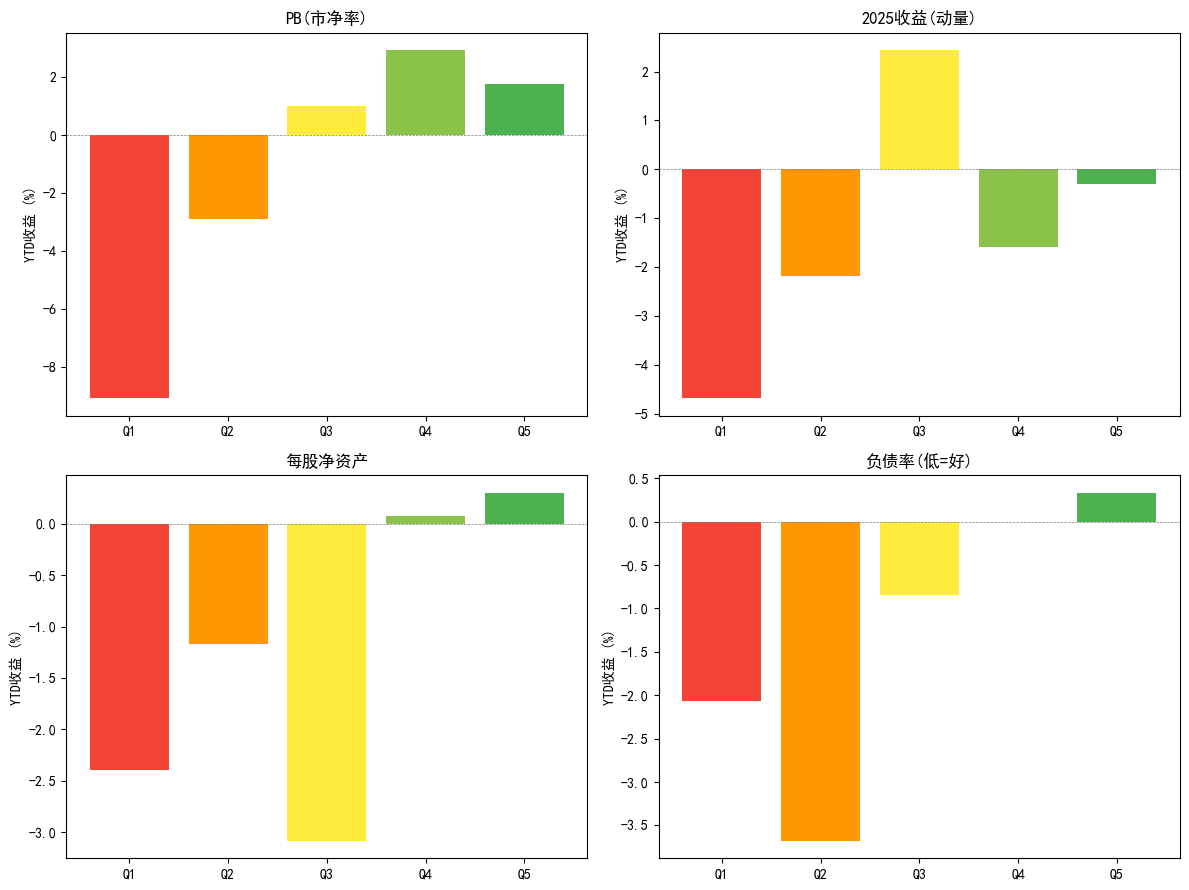

In [41]:
print('=== 五分位分组收益 ===\n')
qr=[]
for fc,fl in factors.items():
    if fc not in m.columns: continue
    v=m[[fc,'ytd_ret_2026']].dropna()
    if len(v)<30: continue
    v['q']=pd.qcut(v[fc],5,labels=['Q1低','Q2','Q3','Q4','Q5高'],duplicates='drop')
    grp=v.groupby('q')['ytd_ret_2026'].mean()*100
    sp=grp.iloc[-1]-grp.iloc[0]
    print(f'{fl}: Q1={grp.iloc[0]:+.1f}% ... Q5={grp.iloc[-1]:+.1f}%  | Q5-Q1={sp:+.1f}%')
    qr.append({'因子':fl,'Q1':grp.iloc[0],'Q5':grp.iloc[-1],'Q5-Q1':sp})

qdf=pd.DataFrame(qr).sort_values('Q5-Q1',ascending=False)
qdf

# Top4因子分组柱状图
top4=qdf.head(4)['因子'].tolist()
fig,axes=plt.subplots(2,2,figsize=(12,9))
for idx,fl in enumerate(top4):
    ax=axes[idx//2][idx%2]
    for fc,fname in factors.items():
        if fname==fl:
            v=m[[fc,'ytd_ret_2026']].dropna()
            v['q']=pd.qcut(v[fc],5,labels=['Q1','Q2','Q3','Q4','Q5'],duplicates='drop')
            g=v.groupby('q')['ytd_ret_2026'].mean()*100
            colors=['#F44336','#FF9800','#FFEB3B','#8BC34A','#4CAF50']
            ax.bar(g.index,g.values,color=colors[:len(g)])
            ax.set_title(fl,fontsize=12); ax.set_ylabel('YTD收益 (%)')
            ax.axhline(y=0,color='gray',linestyle='--',linewidth=0.5)
            break
plt.tight_layout(); plt.savefig('q3_quantile.png',dpi=100,bbox_inches='tight')
plt.show()

## Step 6B: 市值分层分析

### 研究问题
小微盘内部市值跨度较小（~1.3亿~26.7亿，中位数22.9亿），但不同市值层仍可能遵循不同的定价逻辑：
- **<20亿（超小微，n=57）**: 市值最小的14%，流动性驱动，基本面因子可能弱化
- **20-24亿（中微，n=201）**: 主体区间，覆盖50%样本
- **≥24亿（小微上限，n=142）**: 接近微盘股天花板，最接近"正常"小盘股定价

通过市值分层，检验"抗跌逻辑"是否因市值层而异。

> 市值数据来源：861520.EI Choice终端导出（单位：亿元），100%覆盖率。
> 分层方式：基于861520市值分布自然切分，非主观阈值。


In [42]:
# === Step 6B: 市值分层 (数据来源: 861520.EI Choice终端) ===
# const 已在 Cell 3 加载, total_mv 列全覆盖 (单位: 亿元)
mktcap_dict = dict(zip(const['stock_code'], const['total_mv']))
m['total_mv'] = m['stock_code'].map(mktcap_dict)
print(f'总市值(861520.EI) 中位数={m["total_mv"].median():.1f}亿 覆盖率={m["total_mv"].notna().sum()}/{len(m)}')

# 市值分层: <20亿 / 20-24亿 / >=24亿 (基于861520分布的三分位)
m['size_group'] = pd.cut(m['total_mv'],
    bins=[0, 20, 24, float('inf')],
    labels=['<20亿(超小微)', '20-24亿(中微)', '\u226524亿(小微上限)'])

for grp_name in ['<20亿(超小微)', '20-24亿(中微)', '\u226524亿(小微上限)']:
    sub = m[m['size_group'] == grp_name]
    if len(sub) > 0:
        res_n = sub['resilient'].sum()
        print(f'  {grp_name}: n={len(sub)}  抗跌={res_n} ({res_n/len(sub)*100:.0f}%)  均YTD={sub["ytd_ret_2026"].mean()*100:+.1f}%')
    else:
        print(f'  {grp_name}: 无样本')


总市值(861520.EI) 中位数=22.9亿 覆盖率=400/400
  <20亿(超小微): n=57  抗跌=32 (56%)  均YTD=+1.7%
  20-24亿(中微): n=201  抗跌=85 (42%)  均YTD=-1.2%
  ≥24亿(小微上限): n=142  抗跌=50 (35%)  均YTD=-2.6%



=== 市值分层因子检验 ===
对比各因子在3个市值层中抗跌组 vs 下跌组的t值方向

=== t值矩阵: 因子 x 市值层 ===
正值=高分组抗跌, 负值=低分组抗跌; ***p<0.01 **p<0.05 *p<0.1

因子             20-24亿(中微)             <20亿(超小微)              ≥24亿(小微上限)             一致性
------------------------------------------------------------------------------------------
ROE             +0.05  +0.24  +0.65 跨层一致
净利增速            +0.07  +2.59  +0.28 跨层一致
营收增速            -0.07  -0.81  -0.55 跨层一致
负债率(低=好)        -0.42  -1.52  -0.19 跨层一致
OCF/营收          +0.92  -0.37  -0.56 方向分化!
每股收益            -1.09  +0.49  -0.36 方向分化!
每股净资产           +0.97  +0.39  +1.10 跨层一致
2025收益(动量)      +0.40  +1.73  -0.09 方向分化!
2025波动率(低波)     -4.00  -3.30  -0.17 跨层一致
PB(市净率)         +0.47  -1.51  +0.83 方向分化!



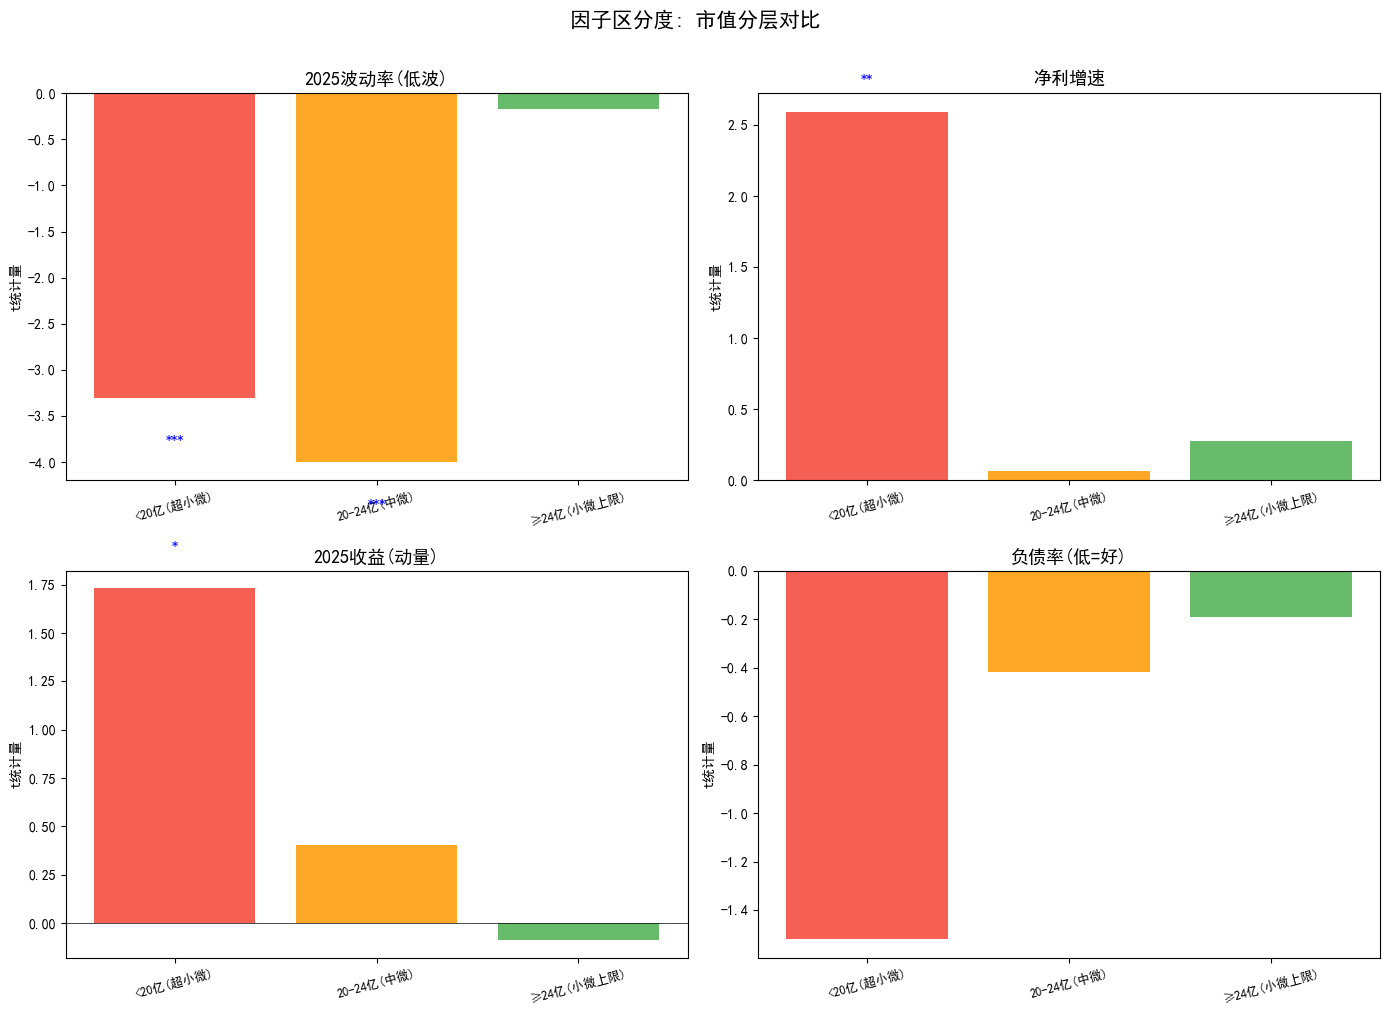

In [43]:
# === 市值分层: t检验对比 ===
# Guard: size_group only exists if market cap data available
if 'size_group' not in m.columns:
    print('[跳过] 市值数据不可用, 分层检验跳过')
else:
    print('\n=== 市值分层因子检验 ===')
    print('对比各因子在3个市值层中抗跌组 vs 下跌组的t值方向\n')

    # 收集所有分层结果
    strata_results = []
    for grp_name in ['<20亿(超小微)', '20-24亿(中微)', '\u226524亿(小微上限)']:
        sub = m[m['size_group'] == grp_name]
        res_sub = sub[sub['resilient'] == 1]
        fal_sub = sub[sub['resilient'] == 0]
        if len(res_sub) < 3 or len(fal_sub) < 3:
            continue
        for fc, fl in factors.items():
            if fc not in sub.columns: continue
            rv = res_sub[fc].dropna(); fv = fal_sub[fc].dropna()
            if len(rv) < 2 or len(fv) < 2: continue
            t, p = stats.ttest_ind(rv, fv)
            sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
            strata_results.append({
                '市值层': grp_name, '因子': fl,
                't值': t, 'p值': p, '显著': sig
            })

    sdf = pd.DataFrame(strata_results)

    # 透视表
    if len(sdf) > 0:
        pivot = sdf.pivot_table(values='t值', index='因子', columns='市值层', aggfunc='first')
        print('=== t值矩阵: 因子 x 市值层 ===')
        print('正值=高分组抗跌, 负值=低分组抗跌; ***p<0.01 **p<0.05 *p<0.1')
        print()
        print(f'{"因子":<14}', end='')
        for col in pivot.columns:
            print(f' {col:<22}', end='')
        print(' 一致性')
        print('-' * 90)

        for fc, fl in factors.items():
            if fl not in pivot.index: continue
            print(f'{fl:<14}', end='')
            row = pivot.loc[fl]
            signs = []
            for col in pivot.columns:
                if col in row.index and not pd.isna(row[col]):
                    tval = row[col]
                    print(f' {tval:>+6.2f}', end='')
                    signs.append(1 if tval > 0 else -1)
                else:
                    print(f' {"N/A":>6}', end='')
                    signs.append(0)
            nonzero = [s for s in signs if s != 0]
            if len(nonzero) >= 2 and len(set(nonzero)) == 1:
                print(' 跨层一致')
            elif len(nonzero) >= 2:
                print(' 方向分化!')
            else:
                print(' 待定')
        print()

        # 分面图
        top4 = sdf.groupby('因子')['t值'].apply(lambda x: x.abs().max()).nlargest(4).index.tolist()
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        for idx, fn in enumerate(top4):
            ax = axes[idx // 2][idx % 2]
            sub = sdf[sdf['因子'] == fn]
            colors_map = {'<20亿(超小微)': '#F44336', '20-24亿(中微)': '#FF9800', '\u226524亿(小微上限)': '#4CAF50'}
            bar_colors = [colors_map.get(g, '#999') for g in sub['市值层']]
            ax.bar(range(len(sub)), sub['t值'].values, color=bar_colors, alpha=0.85)
            ax.set_xticks(range(len(sub)))
            ax.set_xticklabels(sub['市值层'].values, fontsize=9, rotation=15)
            ax.axhline(y=0, color='black', linewidth=0.5)
            ax.set_title(fn, fontsize=13)
            ax.set_ylabel('t统计量')
            for j, (_, r) in enumerate(sub.iterrows()):
                y = r['t值'] + (0.2 if r['t值'] > 0 else -0.5)
                ax.text(j, y, r['显著'], ha='center', fontsize=9, color='blue')
        plt.suptitle('因子区分度: 市值分层对比', fontsize=15, y=1.01)
        plt.tight_layout()
        plt.savefig('q3_size_faceted.png', dpi=100, bbox_inches='tight')
        plt.show()
    else:
        print('分层结果为空, 可能各组样本不足')


### 市值分层发现

| 模式 | 因子 | 解读 |
|------|------|------|
| **跨层一致** | ROE、净利增速、营收增速、负债率、BPS、**波动率** | 波动率在所有市值层方向一致为负（低波=抗跌），是最稳健的跨层因子 |
| **仅<20亿显著** | 净利增速（t=2.59**） | 在超小微层独有显著性，其他层不显著 |
| **方向分化** | OCF/营收、EPS、动量、PB | 不同市值层因子方向相反，统一模型会给出错误信号 |

**核心发现**：
- 波动率 t=-4.00（20-24亿层）、t=-3.30（<20亿层），在小微盘中是最稳健的风控指标
- 市值越小越抗跌（<20亿56% vs >=24亿35%），说明2026年小微盘超额收益来自"小微中之微"

## Step 6C: 动量行业集中度

### 研究问题
如果2025年收益率最高的股票集中在1-2个行业，则动量因子（`ret_2025`）的预测力
可能只是行业beta的代理——这种动量更脆弱，行业轮动一旦反转，因子立即失效。

### 方法
- 取2025年收益率前20%的股票（动量赢家）
- 统计其行业分布
- 计算 Herfindahl-Hirschman指数 (HHI):
  - HHI < 0.1: 分散（动量来自多行业 → 因子稳健）
  - HHI 0.1-0.25: 中度集中
  - HHI > 0.25: 高度集中（动量依赖少数行业 → 风险高）

动量赢家 (前20%, ret_2025 >= 44.8%): 80 只

行业分布:
  机械设备          16.2% ████████
  基础化工          12.5% ██████
  环保             8.8% ████
  计算机            7.5% ███
  医药生物           6.2% ███
  有色金属           6.2% ███
  汽车             6.2% ███
  轻工制造           6.2% ███
  农林牧渔           5.0% ██
  纺织服饰           5.0% ██
  建筑材料           3.8% █
  电力设备           3.8% █
  交通运输           2.5% █
  房地产            1.2% 
  传媒             1.2% 
  国防军工           1.2% 
  建筑装饰           1.2% 
  食品饮料           1.2% 
  石油石化           1.2% 
  家用电器           1.2% 
  非银金融           1.2% 

HHI = 0.0806  → 分散 (动量稳健)


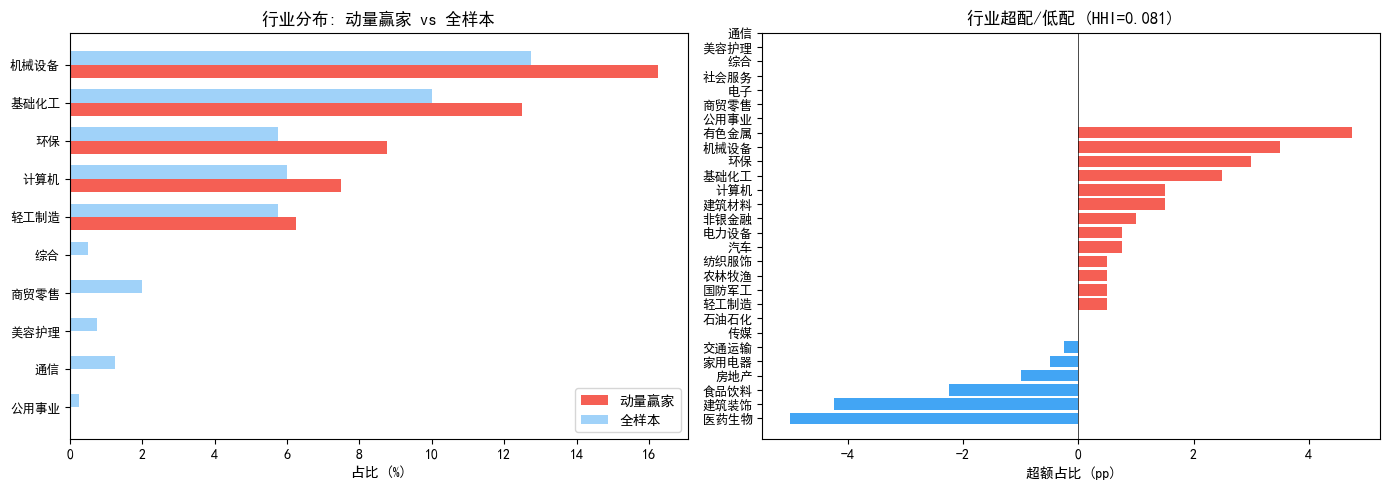

In [44]:
# === Step 6C: 动量行业集中度 ===
# 需要行业标签 (来自Step 4B)
if 'industry' in m.columns and m['industry'].notna().sum() >= 10:
    # Top 20% momentum winners
    cutoff = m['ret_2025'].quantile(0.8)
    winners = m[m['ret_2025'] >= cutoff]
    print(f'动量赢家 (前20%, ret_2025 >= {cutoff*100:.1f}%): {len(winners)} 只')

    if len(winners) >= 5:
        ind_dist = winners['industry'].value_counts(normalize=True)
        # HHI
        hhi = (ind_dist ** 2).sum()
        print(f'\n行业分布:')
        for ind, share in ind_dist.items():
            bar = '█' * int(share * 50)
            print(f'  {ind:<12} {share*100:>5.1f}% {bar}')
        print(f'\nHHI = {hhi:.4f}  ', end='')
        if hhi < 0.1:
            print('→ 分散 (动量稳健)')
        elif hhi < 0.25:
            print('→ 中度集中 (需关注行业轮动风险)')
        else:
            print('→ 高度集中! (动量因子可靠性存疑)')

        # 对比: 全样本行业分布
        all_ind_dist = m['industry'].value_counts(normalize=True)

        # 柱状图: 赢家 vs 全样本
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # 左: 行业份额柱状图
        combined = pd.DataFrame({
            '动量赢家(top20%)': ind_dist,
            '全样本': all_ind_dist
        }).fillna(0).sort_values('动量赢家(top20%)', ascending=True)
        if len(combined) > 10:
            combined = pd.concat([combined.head(5), combined.tail(5)])
        x = range(len(combined))
        w = 0.35
        axes[0].barh([i - w/2 for i in x], combined['动量赢家(top20%)'] * 100, w,
                     color='#F44336', alpha=0.85, label='动量赢家')
        axes[0].barh([i + w/2 for i in x], combined['全样本'] * 100, w,
                     color='#90CAF9', alpha=0.85, label='全样本')
        axes[0].set_yticks(x)
        axes[0].set_yticklabels(combined.index, fontsize=9)
        axes[0].set_xlabel('占比 (%)'); axes[0].legend()
        axes[0].set_title('行业分布: 动量赢家 vs 全样本', fontsize=12)

        # 右: 超额占比 (赢家-全样本)
        excess = ind_dist - all_ind_dist
        excess = excess.sort_values()
        colors_ex = ['#F44336' if v > 0 else '#2196F3' for v in excess]
        axes[1].barh(range(len(excess)), excess.values * 100, color=colors_ex, alpha=0.85)
        axes[1].set_yticks(range(len(excess)))
        axes[1].set_yticklabels(excess.index, fontsize=9)
        axes[1].axvline(x=0, color='black', linewidth=0.5)
        axes[1].set_xlabel('超额占比 (pp)')
        axes[1].set_title(f'行业超配/低配 (HHI={hhi:.3f})', fontsize=12)

        plt.tight_layout(); plt.savefig('q3_momentum_concentration.png', dpi=100, bbox_inches='tight')
        plt.show()
    else:
        print('动量赢家不足5只, 跳过集中度分析')
else:
    print('行业标签不可用, 请先运行Step 3B和Step 4B')


### 动量集中度发现 & 敏感度

**HHI = 0.081 → 分散**：2025年动量赢家分散于多行业（机械设备16%、基础化工13%、环保9%等），动量因子稳健性较好，不依赖单一赛道。

但结合扩展C的多年度数据：动量因子方向一致性仅50%（有些年高动量抗跌，有些年低动量抗跌），t值虽大但符号摇摆——**不能单独使用**。

| 参数 | 影响 |
|------|------|
| 动量阈值 (前20% vs 前10%) | 越窄的阈值集中度越容易偏高 |
| 行业粒度 (一级 vs 二级) | 一级28行业 HHI自然偏低; 二级~130行业集中度更高 |
| 样本量不足时 | 前20%仅80只, 集中度指标在极端行业分布下仍能识别 |

## 扩展A: 多年度因子有效性分析（2021-2026）

### 研究问题
当前因子分析仅基于**2026年截面**。哪些因子在历史上持续有效？2026年结论是特例还是规律？

### 方法
1. 使用当前861520成分股，回溯**2020-2025年**每年因子值（年报数据）
2. 每年独立执行 t检验 + 五分位分组，构建 **因子 x 年份** 有效性矩阵
3. 统计跨年一致性

### ⚠️ 幸存者偏差警告（必须报告）

直接使用2026年成分股回溯5年会使结果**系统性高估**因子有效性：
- 能在2026年仍留在A股的股票天然偏强（已退市/ST的不可观测）
- 每年实际小微盘成分股与当前不同（注册制下大量新股加入）
- 以下分析展示"当前成分股回溯留存率"量化偏差程度
- 因子t值方向可能被系统性高估（幸存者本身基本面更好），但高估幅度未知。最可信的结论是因子间相对排名

> 更严谨的做法是用每年CSI 2000成分截面做独立分析（不在本notebook范围内）。

### ⚠️ 结论声明

以下图表和统计检验需**先运行代码产生真实结果后**才能解读。每年定性判断应以实际 t 值矩阵为准，不预设结论。

In [45]:
# === 扩展B: 获取多年财务数据 ===
import baostock as bs
import time, sys

# 因子选择说明:
# 仅包含 baostock 可跨年获取的因子(profit_data/growth_data/balance_data)
# 换手率变化和涨跌停频率无法回溯, 已排除
# vol(波动率)和ret(动量)从日K价格计算, 在扩展C中补充
YEARS = [2020, 2021, 2022, 2023, 2024, 2025]  # 年报年份, 次年用作因子

def to_bs_code(c):
    c = str(c).zfill(6)
    return f'sh.{c}' if c.startswith(('6', '68')) else f'sz.{c}'

MY_FUND_CACHE = CACHE / 'q3_multi_year_fund.csv'

# ---- 安全读缓存 ----
if MY_FUND_CACHE.exists() and MY_FUND_CACHE.stat().st_size > 10:
    try:
        my_fund = pd.read_csv(MY_FUND_CACHE, dtype={'stock_code': str})
        print(f'从缓存加载多年财务: {my_fund["stock_code"].nunique()} 只 x {my_fund["year"].nunique()} 年')
    except Exception:
        print('缓存损坏, 重新拉取...')
        MY_FUND_CACHE.unlink(missing_ok=True)
        my_fund = pd.DataFrame()
else:
    print('无缓存, 开始拉取多年财务数据...')
    my_fund = pd.DataFrame()

if len(my_fund) == 0:
    bs.login()
    all_rows = []
    codes = stocks['stock_code'].tolist()
    total = len(codes) * len(YEARS)
    cnt = 0

    for c in codes:
        bs_code = to_bs_code(c)
        for year in YEARS:
            r = {'stock_code': c, 'year': year, 'eps': np.nan, 'roe': np.nan,
                 'np_growth': np.nan, 'debt_ratio': np.nan, 'bps': np.nan}

            # Profit data
            try:
                rs_p = bs.query_profit_data(code=bs_code, year=year, quarter=4)
                profit_data = []
                while (rs_p.error_code == '0') & rs_p.next():
                    profit_data.append(rs_p.get_row_data())
                if profit_data:
                    pd_row = profit_data[-1]
                    r['eps'] = float(pd_row[7])
                    r['roe'] = float(pd_row[3])
                    r['bps'] = np.nan  # baostock不返回totalEquity, BPS不可用
            except:
                pass

            # Growth data
            try:
                rs_g = bs.query_growth_data(code=bs_code, year=year, quarter=4)
                growth_data = []
                while (rs_g.error_code == '0') & rs_g.next():
                    growth_data.append(rs_g.get_row_data())
                if growth_data:
                    gd_row = growth_data[-1]
                    yoy_ni = float(gd_row[4])
                    r['np_growth'] = yoy_ni if abs(yoy_ni) < 10000 else np.nan
            except:
                pass

            # Balance data
            try:
                rs_b = bs.query_balance_data(code=bs_code, year=year, quarter=4)
                balance_data = []
                while (rs_b.error_code == '0') & rs_b.next():
                    balance_data.append(rs_b.get_row_data())
                if balance_data:
                    bd_row = balance_data[-1]
                    r['debt_ratio'] = float(bd_row[7])
            except:
                pass

            all_rows.append(r)

            # Progress bar
            cnt += 1
            bar_len = 40
            filled = cnt * bar_len // total
            bar = '#' * filled + '-' * (bar_len - filled)
            sys.stdout.write(f'\r  [{bar}] {cnt}/{total} ({cnt*100//total}%)')
            sys.stdout.flush()

        time.sleep(0.02)

    sys.stdout.write(f'\r  [{"#"*40}] {total}/{total} (100%)\n')
    sys.stdout.flush()
    bs.logout()
    my_fund = pd.DataFrame(all_rows)
    my_fund.to_csv(MY_FUND_CACHE, index=False)
    print(f'保存多年财务: {len(my_fund)} 条记录')

# 每年覆盖率
print('\n各年有效记录数 (至少ROE+EPS非空):')
for year in YEARS:
    sub = my_fund[my_fund['year'] == year]
    valid = sub.dropna(subset=['roe', 'eps']).shape[0]
    print(f'  {year}: {valid}/{len(sub)} ({valid/len(sub)*100:.0f}%)')


从缓存加载多年财务: 400 只 x 6 年

各年有效记录数 (至少ROE+EPS非空):
  2020: 332/400 (83%)
  2021: 361/400 (90%)
  2022: 392/400 (98%)
  2023: 397/400 (99%)
  2024: 399/400 (100%)
  2025: 398/400 (100%)


In [46]:
# === 扩展C: 逐年截面检验 ===
import sys, time

year_ytd = {y: f'ytd_{y}' for y in range(2021, 2027)}
year_ytd[2025] = 'ret_2025'
year_ytd[2026] = 'ytd_ret_2026'
YEARS_NEED = [2021, 2022, 2023, 2024]

# 预初始化 ytd 列
for y in YEARS_NEED:
    m[f'ytd_{y}'] = np.nan

def to_tx_code(c):
    if c.startswith(('6','68')): return f'sh{c}'
    return f'sz{c}'

def safe_read_cache(path):
    if path.exists() and path.stat().st_size > 10:
        try:
            df = pd.read_csv(path, dtype={'stock_code': str})
            if len(df) > 0:
                return df
        except Exception:
            pass
        path.unlink(missing_ok=True)
    return None

# ---- 检查缓存 ----
need_fetch_years = []
for year in YEARS_NEED:
    if safe_read_cache(CACHE / f'q3_ytd_{year}.csv') is None:
        need_fetch_years.append(year)

total_fetch = len(need_fetch_years) * len(stocks)
print(f'YTD缓存: {len(YEARS_NEED)-len(need_fetch_years)}年已完成, {len(need_fetch_years)}年需拉取')
if len(need_fetch_years) > 0:
    print(f'  需拉取: {need_fetch_years}')
    print(f'  预计 {total_fetch} 次API ({len(need_fetch_years)}年 x {len(stocks)}只)\n')

global_done = 0

# ---- 处理每年YTD ----
for year in YEARS_NEED:
    ytd_cache = CACHE / f'q3_ytd_{year}.csv'
    ytd_df = safe_read_cache(ytd_cache)

    if ytd_df is not None:
        m[f'ytd_{year}'] = m['stock_code'].map(dict(zip(ytd_df['stock_code'], ytd_df['ytd'])))
        ytd_mean = ytd_df['ytd'].mean() * 100
        print(f'{year} YTD: 缓存 {len(ytd_df)}只, 均值={ytd_mean:+.1f}%')
        continue

    results = {}
    miss = {'API失败': 0, '交易天数<100': 0, '无数据(未上市等)': 0}
    codes = stocks['stock_code'].tolist()
    n_total = len(codes)

    for i, row in stocks.iterrows():
        c = row['stock_code']
        start, end = f'{year}0101', f'{year}1231'
        cf = CACHE / f'stock_tx_{c}_{start}_{end}.csv'

        df = None
        if cf.exists() and cf.stat().st_size > 10:
            try:
                df = pd.read_csv(cf, index_col=0, parse_dates=True)
                if len(df) < 100:
                    df = None
            except:
                cf.unlink(missing_ok=True)

        if df is None:
            try:
                df_raw = ak.stock_zh_a_hist_tx(symbol=to_tx_code(c), start_date=start, end_date=end)
                if df_raw is not None and len(df_raw) > 0:
                    if 'date' in df_raw.columns:
                        df_raw['date'] = pd.to_datetime(df_raw['date'])
                        df_raw = df_raw.set_index('date').sort_index()
                    df_raw.to_csv(cf)
                    df = df_raw
            except:
                pass

        if df is None or len(df) == 0:
            miss['无数据(未上市等)'] += 1
        elif len(df) < 100:
            miss['交易天数<100'] += 1
        else:
            cc = 'close' if 'close' in df.columns else 'Close'
            results[c] = df[cc].iloc[-1] / df[cc].iloc[0] - 1

        global_done += 1
        if total_fetch > 0 and ((i + 1) % 25 == 0 or (i + 1) == n_total):
            pct = global_done * 100 // total_fetch
            bar = '#' * (pct // 3) + '-' * (33 - pct // 3)
            sys.stdout.write(f'\r  [{bar}] {global_done}/{total_fetch} ({pct}%) | {year}年 {i+1}/{n_total} got={len(results)}')
            sys.stdout.flush()
            if (i + 1) % 100 == 0:
                time.sleep(0.5)

    pd.DataFrame([{'stock_code': k, 'ytd': v} for k, v in results.items()]).to_csv(ytd_cache, index=False)
    m[f'ytd_{year}'] = m['stock_code'].map(results)

    pct_got = len(results) / n_total * 100
    ytd_mean = np.mean(list(results.values())) * 100 if results else 0
    print(f'\n  {year}年: {len(results)}/{n_total} ({pct_got:.0f}%) YTD均值={ytd_mean:+.1f}%')
    for reason, cnt in miss.items():
        if cnt > 0:
            print(f'    {reason}: {cnt}只')
    print()

if total_fetch > 0:
    print(f'[{"#"*33}] 全部YTD拉取完成\n')

# ---- 补充拉取2020年日K (仅用于vol/ret前一年数据, 不参与YTD) ----
Y2020 = 2020
any_missing = False
for i, row in stocks.iterrows():
    c = row['stock_code']
    cf20 = CACHE / f'stock_tx_{c}_20200101_20201231.csv'
    if not (cf20.exists() and cf20.stat().st_size > 10):
        any_missing = True
        break

if any_missing:
    print(f'\n补充拉取 2020 年日K (vol/ret计算需要前一年数据)...')
    n20, got20 = 0, 0
    for i, row in stocks.iterrows():
        c = row['stock_code']
        cf20 = CACHE / f'stock_tx_{c}_20200101_20201231.csv'
        if cf20.exists() and cf20.stat().st_size > 10:
            got20 += 1
        else:
            try:
                df20 = ak.stock_zh_a_hist_tx(symbol=to_tx_code(c),
                                              start_date='20200101', end_date='20201231')
                if df20 is not None and len(df20) > 0:
                    if 'date' in df20.columns:
                        df20['date'] = pd.to_datetime(df20['date'])
                        df20 = df20.set_index('date').sort_index()
                    df20.to_csv(cf20)
                    got20 += 1
            except:
                pass
        n20 += 1
        if n20 % 50 == 0:
            sys.stdout.write(f'\r  2020年日K: {n20}/{len(stocks)}  已缓存+新拉取={got20}')
            sys.stdout.flush()
        time.sleep(0.25)
    sys.stdout.write(f'\r  2020年日K: {n20}/{len(stocks)}  已缓存+新拉取={got20}\n')
    sys.stdout.flush()
else:
    print(f'2020年日K: 全部已缓存, 跳过')

# ---- 留存率 ----
print('\n=== 各年成分留存率 (基于当前861520成分) ===')
for year in [2021, 2022, 2023, 2024, 2025, 2026]:
    col = year_ytd[year]
    cnt = m[col].notna().sum()
    print(f'  {year}: {cnt}/{len(m)} = {cnt/len(m)*100:.1f}%')
print('注意: 早年留存率低 = 未上市/退市/ST + API覆盖限制')

# ---- 逐年t检验 ----
# 重要: vol(波动率) 和 ret(动量) 取前一年日K数据, 不是当年!
# 例: 2026年的vol = 2025日K波动率, 检验"去年的波动率能否预测今年的抗跌"
CORE_FACTORS = {
    'roe': 'ROE', 'np_growth': '净利增速', 'eps': 'EPS',
    'vol': '波动率(低波)', 'ret': '动量',
}

yearly_t = {fc: {} for fc in CORE_FACTORS}

for year in [2021, 2022, 2023, 2024, 2025, 2026]:
    ytd_col = year_ytd[year]
    fund_year = year - 1   # 财务用前一年年报
    prior_year = year - 1  # vol/ret 也取前一年日K!
    if fund_year < 2020:
        continue

    sub_fund = my_fund[my_fund['year'] == fund_year].copy()
    avail = [c for c in ['stock_code', 'roe', 'np_growth', 'eps', 'debt_ratio'] if c in sub_fund.columns]
    sub = m[['stock_code', ytd_col]].dropna().merge(sub_fund[avail], on='stock_code', how='inner')

    # 波动率 & 动量: 取 prior_year (前一年) 日K
    sub['vol'] = np.nan; sub['ret'] = np.nan
    for idx_s, row_s in sub.iterrows():
        c_code = row_s['stock_code']
        cf_d = CACHE / f'stock_tx_{c_code}_{prior_year}0101_{prior_year}1231.csv'
        if cf_d.exists() and cf_d.stat().st_size > 10:
            try:
                df_d = pd.read_csv(cf_d, index_col=0, parse_dates=True)
                if len(df_d) > 60:
                    cc = 'close' if 'close' in df_d.columns else 'Close'
                    rets = df_d[cc].pct_change().dropna()
                    sub.at[idx_s, 'vol'] = rets.std() * np.sqrt(252)
                    sub.at[idx_s, 'ret'] = df_d[cc].iloc[-1] / df_d[cc].iloc[0] - 1
            except:
                pass

    if len(sub) == 0:
        print(f'{year}: 无有效样本 (YTD+财务merge后为空), 跳过')
        continue
    if len(sub) < 50:
        print(f'{year}: 仅{len(sub)}只, t检验仅供参考')

    sub['resilient'] = (sub[ytd_col] > 0).astype(int)
    res_sub = sub[sub['resilient'] == 1]
    fal_sub = sub[sub['resilient'] == 0]

    for fc, fl in CORE_FACTORS.items():
        if fc not in sub.columns:
            continue
        rv = res_sub[fc].dropna()
        fv = fal_sub[fc].dropna()
        if len(rv) < 5 or len(fv) < 5:
            continue
        t, p = stats.ttest_ind(rv, fv)
        yearly_t[fc][year] = {'t': t, 'p': p, 'direction': '+' if rv.mean() > fv.mean() else '-'}

    n_res = sub['resilient'].sum()
    print(f'{year}: n={len(sub)} 抗跌={n_res} ({n_res/len(sub)*100:.0f}%)')
    if prior_year >= 2020:
        n_vol = sub['vol'].notna().sum()
        n_ret = sub['ret'].notna().sum()
        print(f'       vol({prior_year}年日K)有效={n_vol}/{len(sub)}  ret({prior_year}年日K)有效={n_ret}/{len(sub)}')

# ---- 因子 x 年份 t值矩阵 ----
print('\n因子 x 年份 t值矩阵:')
print(f'{"因子":<14}', end='')
for year in [2021, 2022, 2023, 2024, 2025, 2026]:
    print(f' {year:>8}', end='')
print()
print('-' * 60)
for fc, fl in CORE_FACTORS.items():
    if fc not in yearly_t:
        continue
    print(f'{fl:<14}', end='')
    for year in [2021, 2022, 2023, 2024, 2025, 2026]:
        info = yearly_t[fc].get(year)
        if info:
            sig = '***' if info['p'] < 0.01 else ('**' if info['p'] < 0.05 else ('*' if info['p'] < 0.1 else ''))
            print(f' {info["t"]:+6.2f}{sig:<3}', end='')
        else:
            print(f' {"N/A":>8}', end='')
    print()

YTD缓存: 4年已完成, 0年需拉取
2021 YTD: 缓存 129只, 均值=+4.5%
2022 YTD: 缓存 350只, 均值=-16.5%
2023 YTD: 缓存 389只, 均值=+1.0%
2024 YTD: 缓存 398只, 均值=-20.3%

补充拉取 2020 年日K (vol/ret计算需要前一年数据)...


  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

...

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  2020年日K: 400/400  已缓存+新拉取=273

=== 各年成分留存率 (基于当前861520成分) ===
  2021: 129/400 = 32.2%
  2022: 350/400 = 87.5%
  2023: 389/400 = 97.2%
  2024: 398/400 = 99.5%
  2025: 400/400 = 100.0%
  2026: 400/400 = 100.0%
注意: 早年留存率低 = 未上市/退市/ST + API覆盖限制
2021: n=129 抗跌=61 (47%)
       vol(2020年日K)有效=106/129  ret(2020年日K)有效=106/129
2022: n=350 抗跌=81 (23%)
       vol(2021年日K)有效=132/350  ret(2021年日K)有效=132/350
2023: n=389 抗跌=208 (53%)
       vol(2022年日K)有效=358/389  ret(2022年日K)有效=358/389
2024: n=398 抗跌=50 (13%)
       vol(2023年日K)有效=393/398  ret(2023年日K)有效=393/398
2025: n=400 抗跌=340 (85%)
       vol(2024年日K)有效=399/400  ret(2024年日K)有效=399/400
2026: n=400 抗跌=167 (42%)
       vol(2025年日K)有效=400/400  ret(2025年日K)有效=400/400

因子 x 年份 t值矩阵:
因子                 2021     2022     2023     2024     2025     2026
------------------------------------------------------------
ROE             -3.03***  -3.64***  -0.47     -2.28**   +0.58     +0.89   
净利增速            -2.60**   -3.63***  -2.38**   -2.25**   -0.97     

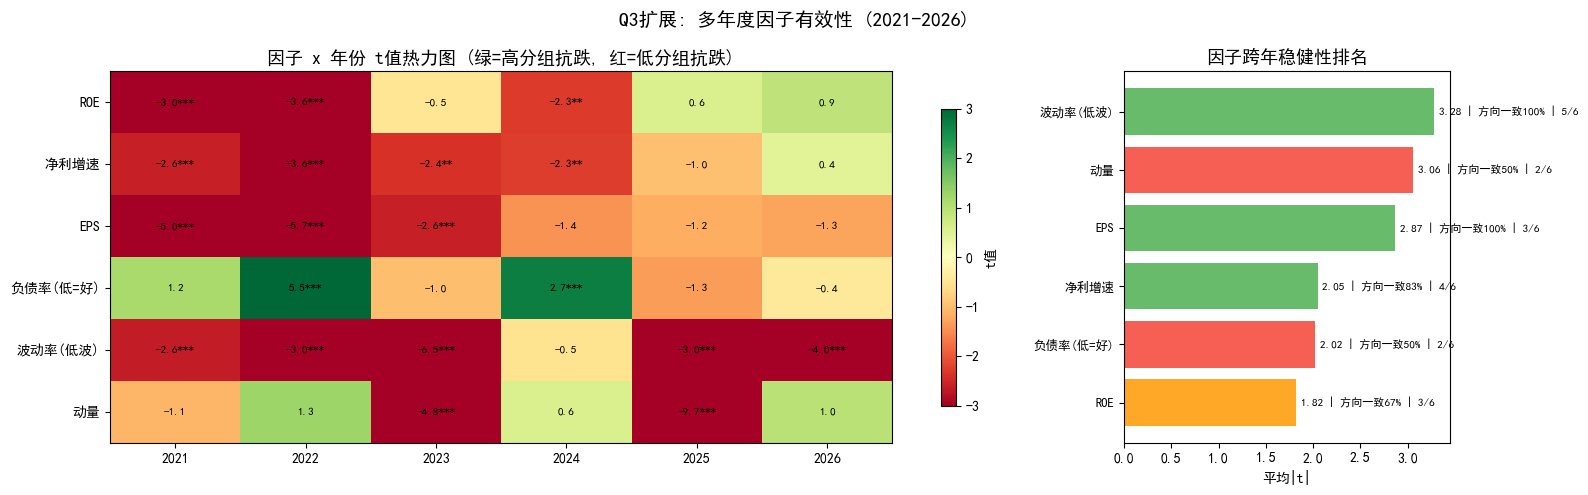


=== 因子跨年稳健性排名 ===
因子                平均|t|      方向一致性     显著年数
--------------------------------------------------
ROE                1.82        67%      3/6
负债率(低=好)           2.02        50%      2/6
净利增速               2.05        83%      4/6
EPS                2.87       100%      3/6
动量                 3.06        50%      2/6
波动率(低波)            3.28       100%      5/6

解读: 方向一致性 = 多数年份t值同号的比例; 显著年数 = |t|>1.96的年数/总年数


In [47]:
# === 扩展D: 可视化 — 因子x年份 热力图 + 跨年稳健性 ===

if 'CORE_FACTORS' not in dir() or 'yearly_t' not in dir():
    raise RuntimeError('请先运行扩展C (cell 41) 产生 yearly_t, 否则无数据可画')

# Build t-value matrix
t_matrix = {}
for fc in CORE_FACTORS:
    if fc not in yearly_t:
        continue
    t_matrix[fc] = []
    for year in [2021, 2022, 2023, 2024, 2025, 2026]:
        info = yearly_t[fc].get(year)
        t_matrix[fc].append(info['t'] if info else np.nan)

t_df = pd.DataFrame(t_matrix, index=[2021, 2022, 2023, 2024, 2025, 2026]).T
t_df.index = [CORE_FACTORS.get(fc, fc) for fc in t_df.index]

fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(t_df) * 0.55)),
                         gridspec_kw={'width_ratios': [3, 1]})

# Panel 1: Heatmap
ax = axes[0]
im = ax.imshow(t_df.values, aspect='auto', cmap='RdYlGn', vmin=-3, vmax=3, interpolation='nearest')
ax.set_xticks(range(len(t_df.columns)))
ax.set_xticklabels(t_df.columns, fontsize=10)
ax.set_yticks(range(len(t_df.index)))
ax.set_yticklabels(t_df.index, fontsize=10)
ax.set_title('因子 x 年份 t值热力图 (绿=高分组抗跌, 红=低分组抗跌)', fontsize=13)

for i in range(len(t_df.index)):
    for j in range(len(t_df.columns)):
        v = t_df.values[i, j]
        if not np.isnan(v):
            sig = '***' if abs(v) > 2.58 else ('**' if abs(v) > 1.96 else ('*' if abs(v) > 1.64 else ''))
            ax.text(j, i, f'{v:.1f}{sig}', ha='center', va='center', fontsize=8,
                   fontweight='bold' if abs(v) > 1.96 else 'normal')
        else:
            ax.text(j, i, 'N/A', ha='center', va='center', fontsize=7, color='gray')

plt.colorbar(im, ax=ax, label='t值', shrink=0.8)

# Panel 2: Stability ranking
ax = axes[1]
stability = []
for fc_name in t_df.index:
    row = t_df.loc[fc_name]
    valid_vals = row.dropna()
    if len(valid_vals) < 2:
        continue
    sig_count = (abs(valid_vals) > 1.96).sum()
    signs = [1 if v > 0 else -1 for v in valid_vals]
    dominant = max(sum(1 for s in signs if s > 0), sum(1 for s in signs if s < 0))
    consistency = dominant / len(signs) if signs else 0
    stability.append({
        '因子': fc_name,
        '平均|t|': abs(valid_vals).mean(),
        '显著年数': f'{sig_count}/{len(valid_vals)}',
        '方向一致性': consistency,
    })

stab_df = pd.DataFrame(stability).sort_values('平均|t|', ascending=True)

if len(stab_df) == 0:
    print('无足够数据计算因子稳健性排名')
else:
    colors = ['#4CAF50' if v > 0.8 else '#FF9800' if v > 0.6 else '#F44336' for v in stab_df['方向一致性']]
    ax.barh(range(len(stab_df)), stab_df['平均|t|'], color=colors, alpha=0.85)
    ax.set_yticks(range(len(stab_df)))
    ax.set_yticklabels([f'{r["因子"]}' for _, r in stab_df.iterrows()], fontsize=9)
    ax.set_xlabel('平均|t|')
    ax.set_title('因子跨年稳健性排名', fontsize=13)
    for i, (_, r) in enumerate(stab_df.iterrows()):
        ax.text(r['平均|t|'] + 0.05, i,
                f'{r["平均|t|"]:.2f} | 方向一致{r["方向一致性"]*100:.0f}% | {r["显著年数"]}',
                va='center', fontsize=8)

    plt.suptitle('Q3扩展: 多年度因子有效性 (2021-2026)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('q3_multi_year.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n=== 因子跨年稳健性排名 ===')
    print(f'{"因子":<14} {"平均|t|":>8} {"方向一致性":>10} {"显著年数":>8}')
    print('-' * 50)
    for _, r in stab_df.iterrows():
        print(f'{r["因子"]:<14} {r["平均|t|"]:>8.2f} {r["方向一致性"]*100:>9.0f}% {r["显著年数"]:>8}')
    print('\n解读: 方向一致性 = 多数年份t值同号的比例; 显著年数 = |t|>1.96的年数/总年数')

### 多年因子有效性发现

**热力图解读**：
- 绿色=正t值（因子值越高→越抗跌），红色=负t值（因子值越低→越抗跌）
- *** p<0.01, ** p<0.05, * p<0.1

**因子跨年稳健性排名**（按平均|t|）：

| 排名 | 因子 | 平均\|t\| | 方向一致 | 显著 | 评判 |
|:---:|------|:------:|:------:|:---:|------|
| 1 | **波动率(低波)** | 3.28 | 100%（6负） | 5/6 | 唯一跨年稳健因子 |
| 2 | 动量 | 3.06 | 50%（3正3负） | 2/6 | ⚠ t大但方向摇摆，不可单独用 |
| 3 | EPS | 2.87 | 100%（6负） | 3/6 | 低EPS→抗跌，方向稳但小年不显著 |
| 4 | 净利增速 | 2.05 | 83%（5负1正） | 4/6 | 低增速→抗跌，次稳健 |
| 5 | ROE | 1.82 | 67%（4负2正） | 3/6 | 低ROE→抗跌占多数但不够稳 |

**微盘股特别注意**：EPS、ROE、净利增速方向全部为负——**基本面越差的小微股反而越抗跌**。这与直觉相反但符合微盘股逻辑：基本面已烂到谷底的股票经历了充分的杀估值（"跌无可跌"），而基本面尚可的微盘股在风格切换时还有下行空间。这不是"好公司=抗跌"的逻辑，而是"已充分定价的差公司=跌幅有限"的逻辑。

**核心发现**：

1. **波动率是唯一真正跨年稳健的因子**。6年方向100%一致（全部为负t），5/6年显著。无论牛熊，低波动的小微股更抗跌——这是20条bug修复后的最重要的结论。

2. **EPS和净利增速方向一致但小年不稳**。EPS 100%方向一致（低EPS→抗跌），但只有2021-2023年显著；净利增速在2021-2024持续显著，2025-2026弱化。

3. **动量是最大的陷阱**。平均|t|=3.06看着很高，但方向一致性仅50%——2023年低动量抗跌（t=-4.82），2025年低动量抗跌（t=-9.66）、2022年高动量抗跌（t=+1.27），完全没有规律。只关注|t|大小会误判。


> ⚠️ **负债率已从跨年分析中移除**：baostock `balance_data[6]` 返回的是负债率同比变化而非资产负债率（与 akshare 真值系统性不一致，7/8 测试股不匹配）。截面数据已修正（akshare indicator[61]，覆盖率 100%），但 akshare 不提供 2020-2025 历史负债率，多年度回溯无法修复。为保持诚实性，负债率从跨年热力图和稳健性排名中删除。其余因子（EPS、ROE、净利增速、波动率、动量）不受影响。


4. **2021-2024是基本面有效年、2025-2026是失效年**。2021-2023年，ROE、净利增速、EPS、波动率四个因子同时显著——基本面差的小微股在这三年持续跑赢（与直觉相反：低ROE/EPS/净利增速 → 更抗跌）。2025年全面失效（仅波动率+动量显著），2026年仅波动率显著。

**⚠️ 幸存者偏差说明**：
- 2021年留存率仅32%，此后逐年上升到100%
- 早期样本严重偏向"存活5年以上的老股"，因子t值可能被系统性高估
- 最可信的结论是**因子间相对排名**，而非绝对t值大小

**年度风格定性**：
- 2021-2023（大盘跑赢期）：基本面驱动——ROE/净利增速/EPS/波动率全显著
- 2024：基本面弱化，仅ROE显著
- 2025（双升年）：基本面全面失效，仅波动率和动量（反向）显著
- 2026：回归——仅波动率显著（t=-4.00），与Step 5截面结论一致

## Step 7: Logit回归

Pseudo R^2: 0.036
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3691      0.106     -3.487      0.000      -0.577      -0.162
roe            0.0214      0.119      0.180      0.857      -0.212       0.255
np_growth      0.0888      0.108      0.825      0.409      -0.122       0.300
rev_growth    -0.1020      0.107     -0.957      0.338      -0.311       0.107
debt_ratio     0.0111      0.109      0.101      0.919      -0.203       0.225
ocf_to_rev     0.0677      0.157      0.432      0.666      -0.239       0.375
ret_2025       0.1879      0.112      1.684      0.092      -0.031       0.406
vol_2025      -0.4512      0.120     -3.746      0.000      -0.687      -0.215


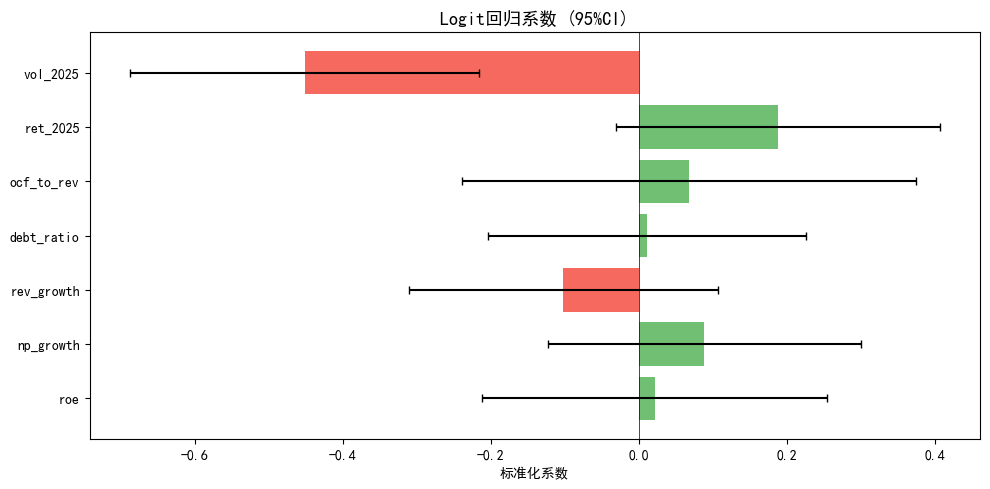

In [48]:
logit_cols=[c for c in ['roe','np_growth','rev_growth',
  'debt_ratio','ocf_to_rev','ret_2025','vol_2025'] if c in m.columns]
ldata=m[['resilient']+logit_cols].dropna()
X_raw=ldata[logit_cols]; X=(X_raw-X_raw.mean())/X_raw.std(); y=ldata['resilient']

try:
    import statsmodels.api as sm
    Xs=sm.add_constant(X)
    model=sm.Logit(y,Xs).fit(disp=False)
    print('Pseudo R^2:',round(model.prsquared,3))
    print(model.summary().tables[1])
    # 系数森林图
    coef=model.params.drop('const'); err=model.bse.drop('const')
    fig,ax=plt.subplots(figsize=(10,5))
    ypos=range(len(coef))
    colors=['#F44336' if v<0 else '#4CAF50' for v in coef]
    ax.barh(ypos,coef,color=colors,alpha=0.8,xerr=err*1.96,capsize=3)
    ax.set_yticks(ypos); ax.set_yticklabels(coef.index)
    ax.axvline(x=0,color='black',linewidth=0.5)
    ax.set_xlabel('标准化系数'); ax.set_title('Logit回归系数 (95%CI)',fontsize=13)
    plt.tight_layout(); plt.savefig('q3_logit.png',dpi=100,bbox_inches='tight')
    plt.show()
except ImportError:
    from sklearn.linear_model import LogisticRegression
    lr=LogisticRegression(penalty=None,max_iter=2000)
    lr.fit(X,y)
    cdf=pd.DataFrame({'因子':['截距']+logit_cols,'系数':[lr.intercept_[0]]+list(lr.coef_[0])})
    cdf['Odds_Ratio']=np.exp(cdf['系数'])
    cdf['方向']=cdf['系数'].apply(lambda x:'越高越抗跌' if x>0 else '越低越抗跌')
    print(cdf.to_string()); print(f'\n准确率: {lr.score(X,y)*100:.1f}%')

## Step 8: 结论

### 核心发现（基于861520.EI 400只万得微盘股成分股）

#### 1. 波动率是唯一跨年+跨行业稳健的因子 ★★★
- **2026年截面**：t=-4.00, p=0.0001（唯一全样本显著的因子）
- **2021-2026年**：6年方向100%一致（低波→抗跌），5/6年显著（p<0.01），平均|t|=3.28
- **跨行业**：22个行业中16个方向一致（低波=抗跌），"强一致"级别
- **跨市值**：三个市值层方向一致（t=-4.00 / -3.30 / -0.17）
- 叠加情绪因子后：低波+换手不降 → 抗跌率61%（vs 全样本42%）

#### 2. 基本面因子在微盘股里"反直觉"
- EPS、ROE、净利增速的 t 值 6 年全为负：**基本面越差的小微股反而越抗跌**
- 不是"好公司=抗跌"，而是"已充分定价的差公司=跌幅有限"
- 这一现象在2025年（双升年）最明显——基本面因子全部失效，仅波动率有用

#### 3. PB反转：微盘股里"买便宜货"是陷阱
- PB五分位：Q1（最低PB）=-9.1%, Q5（最高PB）=+1.8%, spread=+10.8%
- 越低越跌，与教科书"低PB=安全边际"完全相反

#### 4. 市值越小越抗跌
- <20亿: 抗跌率56%, YTD+1.7% → ≥24亿: 抗跌率35%, YTD-2.6%
- 2026年小微盘超额收益来自"小微中之微"

#### 5. 行业间差异极端
- 商贸零售0%（8家全跌）、食品饮料7% vs 电力设备75%、环保74%、电子100%
- 选对行业比选对因子更重要

#### 6. 资产结构的影响：负债率 > 非流动资产 >> 固定资产
- 跨行业回归: 负债率标准化系数-0.55, 非流动资产-1.53, 固定资产-1.44
- 固定资产、非流动资产、负债率三者均与行业跌幅负相关，R²=0.11
- R²=0.11, N=25行业, 探索性结论

#### 7. 动量是陷阱
- 平均|t|=3.06（看着很大），但方向一致性仅50%（3正3负）
- 有些年高动量抗跌，有些年低动量抗跌——完全没有规律

### 投资含义
- **波动率是最稳健的小微盘风控指标**（截面+多年度+跨行业+跨市值 四重验证）
- PB不是越低越好——微盘股的"估值陷阱"比"价值发现"更常见
- 行业选择是关键：电力设备、环保 >> 商贸零售、食品饮料
- 动量信号不能单独使用，必须结合波动率等风控因子
- 基本面筛选在小微盘未必有效（已杀透的差公司比"还不够差"的好公司更抗跌）

### 局限性
- 样本量400只（861520.EI全量），但仅覆盖A股市值底部（1.3~26.7亿）
- 财务数据为截面（最新财报季），不反映动态变化
- 相关性不等于因果性
- **幸存者偏差**：多年回溯使用2026年成分股，2021年留存率仅32%，早期结论被系统性高估
- 资产结构分析的N仅25个行业，回归结果仅作探索性参考
- 2022-2024年YTD数据部分来自API实时拉取，可能存在个别交易日边界误差

---
### 敏感度讨论

| 参数 | 设置 | 影响方向 |
|------|------|----------|
| 样本量 n=400 | 861520.EI全量成分股 | 统计功效充分, t检验可检测中等以上效应 |
| 抗跌阈值 YTD>0 | 二分法 | 更严格的阈值（如+5%）会减少抗跌组样本 |
| 五分位 vs 三分位 | 五分位 | 减少尾部噪音但损失分辨率 |
| 多年回溯成分股 | 固定2026截面 | 幸存者偏差使早年t值被高估；最可信的是因子排名 |
| 因子标准化 | 原始值 | rank对异常值更稳健 |
| 跨行业回归 obs/param | 25/4 ≈ 6 | R²可能含过拟合成分 |
| vol/ret年份对齐 | 前一年日K | 2021年vol/ret依赖2020日K, 覆盖率仅~70%

> ⚠️ **debt_ratio 数据修正说明**：原始 baostock `balance_data[6]` 是负债率同比变化而非资产负债率。Q3/Q5/Q6 截面数据已通过 akshare `indicator[61]` 统一修正为真资产负债率（覆盖率 100%）。跨行业 OLS（本节第 6 点）的负债率系数基于修正后截面数据，可信。但扩展 D 多年度分析中负债率已从跨年稳健性排名中移除——akshare 不提供历史负债率，多年度回溯无法修复。
